In [6]:
# ============================================================
# CELL 1
# ORDINAL + EXPLAINABLE DIABETIC RETINOPATHY
# IMPORTS + GPU CONFIGURATION
# ============================================================

import os
import sys
import gc
import json
import math
import time
import random
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = True

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

# Torchvision
import torchvision
import torchvision.transforms as T
from torchvision import models
from torchvision.models import (
    EfficientNet_B0_Weights,
    DenseNet121_Weights,
    ConvNeXt_Tiny_Weights
)

# Metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    cohen_kappa_score,
    mean_absolute_error,
    mean_squared_error,
    roc_auc_score
)

# Progress bar
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

# ============================================================
# REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ============================================================
# CUDA CONFIGURATION
# ============================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 75)
print("ORDINAL DIABETIC RETINOPATHY PROJECT")
print("=" * 75)

print(f"PyTorch version       : {torch.__version__}")
print(f"Torchvision version   : {torchvision.__version__}")
print(f"CUDA available        : {torch.cuda.is_available()}")
print(f"CUDA version          : {torch.version.cuda}")
print(f"Device                : {DEVICE}")

if torch.cuda.is_available():

    GPU_NAME = torch.cuda.get_device_name(0)

    GPU_MEMORY = (
        torch.cuda.get_device_properties(0).total_memory
        / (1024 ** 3)
    )

    print(f"GPU                   : {GPU_NAME}")
    print(f"GPU memory            : {GPU_MEMORY:.2f} GB")

    # Enable optimized CUDA behavior
    torch.backends.cudnn.benchmark = True

    # TF32 can accelerate matrix operations on supported GPUs
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

else:

    GPU_NAME = "CPU"
    GPU_MEMORY = 0

    print("\nWARNING: CUDA is NOT available.")

# ============================================================
# PERFORMANCE SETTINGS
# ============================================================

# We will adjust this after checking your GPU memory.
BATCH_SIZE = 32

NUM_WORKERS = 0

IMAGE_SIZE = 384

PIN_MEMORY = torch.cuda.is_available()

PERSISTENT_WORKERS = NUM_WORKERS > 0

PREFETCH_FACTOR = 4

USE_AMP = torch.cuda.is_available()

# ============================================================
# AMP SCALER
# ============================================================

if USE_AMP:

    scaler = torch.amp.GradScaler("cuda")

else:

    scaler = None

# ============================================================
# PATHS
# ============================================================

DATASET_ROOT = Path(
    r"C:\Users\cscpr\Downloads\random 3_amra2\dataset"
)

OUTPUT_ROOT = Path("./DR_Ordinal_Results")

CHECKPOINT_DIR = OUTPUT_ROOT / "checkpoints"
FIGURE_DIR = OUTPUT_ROOT / "figures"
LOG_DIR = OUTPUT_ROOT / "logs"

CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

LOG_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("\n" + "=" * 75)
print("CONFIGURATION")
print("=" * 75)

print(f"Dataset              : {DATASET_ROOT}")
print(f"Image size           : {IMAGE_SIZE}")
print(f"Batch size           : {BATCH_SIZE}")
print(f"Workers              : {NUM_WORKERS}")
print(f"AMP                  : {USE_AMP}")
print(f"Pin memory           : {PIN_MEMORY}")

# ============================================================
# MEMORY CHECK
# ============================================================

if torch.cuda.is_available():

    torch.cuda.empty_cache()

    free_memory, total_memory = torch.cuda.mem_get_info()

    print(
        f"GPU free memory      : "
        f"{free_memory / (1024**3):.2f} GB"
    )

    print(
        f"GPU total memory     : "
        f"{total_memory / (1024**3):.2f} GB"
    )

print("\nCell 1 completed successfully.")

ORDINAL DIABETIC RETINOPATHY PROJECT
PyTorch version       : 2.13.0+cu132
Torchvision version   : 0.28.0+cu132
CUDA available        : True
CUDA version          : 13.2
Device                : cuda
GPU                   : NVIDIA GeForce RTX 4050 Laptop GPU
GPU memory            : 6.00 GB

CONFIGURATION
Dataset              : C:\Users\cscpr\Downloads\random 3_amra2\dataset
Image size           : 384
Batch size           : 32
Workers              : 0
AMP                  : True
Pin memory           : True
GPU free memory      : 4.96 GB
GPU total memory     : 6.00 GB

Cell 1 completed successfully.


DIABETIC RETINOPATHY DATASET AUDIT
Total images found: 757

Detected classes:


,images
class_name,
1. No DR signs,187
4. Severe NPDR,176
7. Advanced PDR,114
5. Very Severe NPDR,108
6. PDR,88
3. Moderate NPDR,80
2. Mild (or early) NPDR,4



VERIFYING CLASS STRUCTURE
Dataset contains the expected 7 DR severity classes.

CORRECT ORDINAL CLASS MAPPING
0 -> No DR signs                         187 images
1 -> Mild (or early) NPDR                  4 images
2 -> Moderate NPDR                        80 images
3 -> Severe NPDR                         176 images
4 -> Very Severe NPDR                    108 images
5 -> PDR                                  88 images
6 -> Advanced PDR                        114 images

CLASS IMBALANCE


,images
label,
0,187
1,4
2,80
3,176
4,108
5,88
6,114



Imbalance ratio: 46.75 : 1

DATASET SPLIT
Training   : 530
Validation : 113
Testing    : 114

Training distribution:


...


Validation distribution:


,images
label,
0,28
1,1
2,12
3,26
4,16
5,13
6,17



Test distribution:


,images
label,
0,28
1,1
2,12
3,27
4,16
5,13
6,17



Overall split percentages:
Train      : 70.01%
Validation : 14.93%
Test       : 15.06%

CLASS WEIGHTS
0 | No DR signs                    | 0.5780
1 | Mild (or early) NPDR           | 37.8571
2 | Moderate NPDR                  | 1.3520
3 | Severe NPDR                    | 0.6156
4 | Very Severe NPDR               | 0.9962
5 | PDR                            | 1.2212
6 | Advanced PDR                   | 0.9464

DATALOADERS
Train batches      : 16
Validation batches : 4
Test batches       : 4


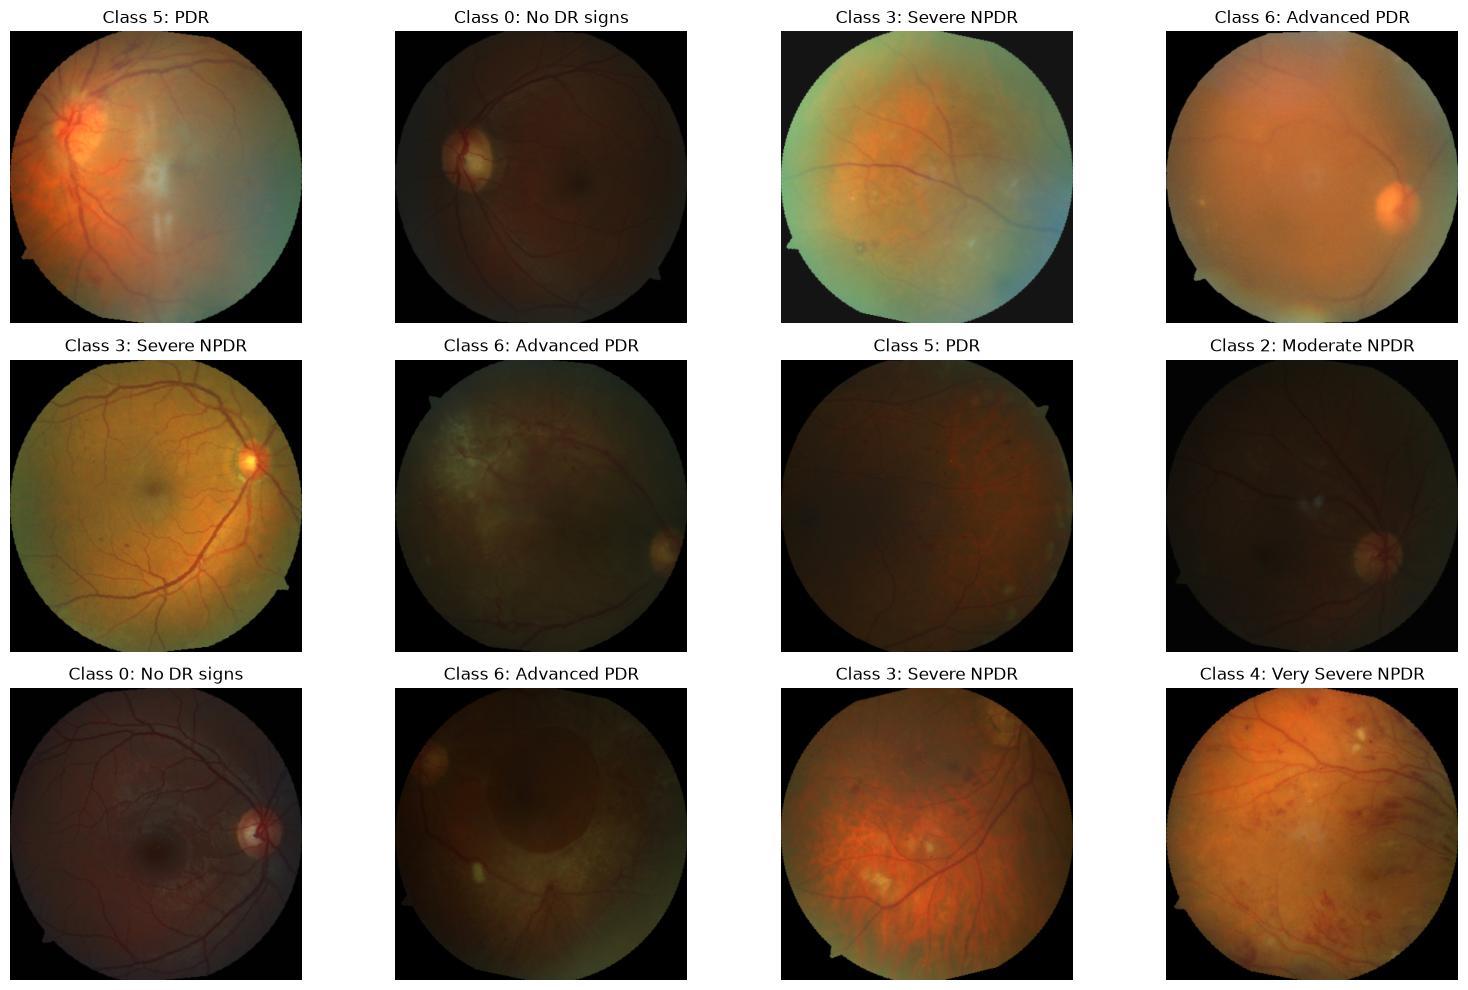


CELL 2 COMPLETED SUCCESSFULLY


In [7]:
# ============================================================
# CELL 2
# DATASET AUDIT + CORRECT 7-CLASS ORDINAL MAPPING
# + RARE-CLASS-AWARE SPLITTING
# + PREPROCESSING + DATALOADERS
# ============================================================

# ============================================================
# CONFIGURATION
# ============================================================

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}

# ============================================================
# DATASET CHECK
# ============================================================

if not DATASET_ROOT.exists():

    raise FileNotFoundError(
        f"Dataset not found:\n{DATASET_ROOT}"
    )

# ============================================================
# DISCOVER IMAGES
# ============================================================

all_images = []

for path in DATASET_ROOT.rglob("*"):

    if (
        path.is_file()
        and path.suffix.lower() in IMAGE_EXTENSIONS
    ):

        all_images.append(path)

print("=" * 75)
print("DIABETIC RETINOPATHY DATASET AUDIT")
print("=" * 75)

print(
    f"Total images found: {len(all_images):,}"
)

if len(all_images) == 0:

    raise RuntimeError(
        "No images found. Check DATASET_ROOT."
    )

# ============================================================
# READ CLASS FROM FIRST DIRECTORY
# ============================================================

records = []

for image_path in all_images:

    relative = image_path.relative_to(
        DATASET_ROOT
    )

    parts = relative.parts

    if len(parts) < 2:

        print(
            "WARNING: Image not inside a class folder:",
            image_path
        )

        continue

    class_name = parts[0]

    records.append({
        "path": str(image_path),
        "class_name": class_name
    })

df = pd.DataFrame(records)

# ============================================================
# EXPECTED DATASET CLASSES
# ============================================================

EXPECTED_CLASSES = {

    "1. No DR signs": 0,

    "2. Mild (or early) NPDR": 1,

    "3. Moderate NPDR": 2,

    "4. Severe NPDR": 3,

    "5. Very Severe NPDR": 4,

    "6. PDR": 5,

    "7. Advanced PDR": 6
}

# ============================================================
# VERIFY DATASET CLASS NAMES
# ============================================================

detected_classes = set(
    df["class_name"].unique()
)

expected_classes = set(
    EXPECTED_CLASSES.keys()
)

print("\nDetected classes:")

display(
    df["class_name"]
    .value_counts()
    .to_frame("images")
)

print("\n" + "=" * 75)
print("VERIFYING CLASS STRUCTURE")
print("=" * 75)

missing_classes = (
    expected_classes
    - detected_classes
)

unexpected_classes = (
    detected_classes
    - expected_classes
)

if missing_classes:

    print(
        "MISSING EXPECTED CLASSES:",
        missing_classes
    )

if unexpected_classes:

    print(
        "UNEXPECTED CLASSES:",
        unexpected_classes
    )

if missing_classes or unexpected_classes:

    raise RuntimeError(
        "\nDataset folder names do not exactly match "
        "the expected 7-class structure.\n\n"
        f"Detected: {sorted(detected_classes)}\n\n"
        f"Expected: {sorted(expected_classes)}"
    )

print(
    "Dataset contains the expected 7 DR severity classes."
)

# ============================================================
# CORRECT ORDINAL MAPPING
# ============================================================

CLASS_MAPPING = EXPECTED_CLASSES.copy()

df["label"] = df["class_name"].map(
    CLASS_MAPPING
)

NUM_CLASSES = 7

# ============================================================
# CLASS NAMES IN ORDINAL ORDER
# ============================================================

CLASS_NAMES = [
    "No DR signs",
    "Mild (or early) NPDR",
    "Moderate NPDR",
    "Severe NPDR",
    "Very Severe NPDR",
    "PDR",
    "Advanced PDR"
]

print("\n" + "=" * 75)
print("CORRECT ORDINAL CLASS MAPPING")
print("=" * 75)

class_counts = (
    df["label"]
    .value_counts()
    .sort_index()
)

for label in range(NUM_CLASSES):

    class_name = CLASS_NAMES[label]

    count = int(
        class_counts.get(label, 0)
    )

    print(
        f"{label} -> "
        f"{class_name:<30} "
        f"{count:>8,} images"
    )

# ============================================================
# CLASS IMBALANCE
# ============================================================

print("\n" + "=" * 75)
print("CLASS IMBALANCE")
print("=" * 75)

display(
    class_counts.to_frame("images")
)

imbalance_ratio = (
    class_counts.max()
    / class_counts.min()
)

print(
    f"\nImbalance ratio: "
    f"{imbalance_ratio:.2f} : 1"
)

# ============================================================
# RARE-CLASS-AWARE SPLITTING
# ============================================================
#
# We deliberately avoid the normal two-stage
# train_test_split(stratify=...)
#
# because Mild NPDR contains only 4 images.
#
# For each class:
#
#   >= 10 images:
#       approximately 70 / 15 / 15
#
#   4 images:
#       2 train / 1 validation / 1 test
#
# ============================================================

def create_rare_class_aware_split(
    dataframe,
    seed=42
):

    rng = np.random.default_rng(seed)

    train_parts = []
    val_parts = []
    test_parts = []

    for label in sorted(
        dataframe["label"].unique()
    ):

        class_df = dataframe[
            dataframe["label"] == label
        ].copy()

        class_df = class_df.sample(
            frac=1,
            random_state=seed + int(label)
        ).reset_index(drop=True)

        n = len(class_df)

        # ----------------------------------------------------
        # Special handling for extremely small class
        # ----------------------------------------------------

        if n == 4:

            n_train = 2
            n_val = 1
            n_test = 1

        elif n == 5:

            n_train = 3
            n_val = 1
            n_test = 1

        elif n == 6:

            n_train = 4
            n_val = 1
            n_test = 1

        elif n == 7:

            n_train = 5
            n_val = 1
            n_test = 1

        else:

            n_train = max(
                1,
                int(round(0.70 * n))
            )

            n_val = max(
                1,
                int(round(0.15 * n))
            )

            n_test = (
                n
                - n_train
                - n_val
            )

            # Guarantee at least one test sample
            if n_test < 1:

                n_test = 1
                n_train -= 1

        # ----------------------------------------------------
        # Make sure totals are correct
        # ----------------------------------------------------

        if (
            n_train
            + n_val
            + n_test
            != n
        ):

            n_train = (
                n
                - n_val
                - n_test
            )

        train_parts.append(
            class_df.iloc[
                :n_train
            ]
        )

        val_parts.append(
            class_df.iloc[
                n_train:
                n_train + n_val
            ]
        )

        test_parts.append(
            class_df.iloc[
                n_train + n_val:
            ]
        )

    train_df = pd.concat(
        train_parts,
        ignore_index=True
    )

    val_df = pd.concat(
        val_parts,
        ignore_index=True
    )

    test_df = pd.concat(
        test_parts,
        ignore_index=True
    )

    # Shuffle each split
    train_df = train_df.sample(
        frac=1,
        random_state=seed
    ).reset_index(drop=True)

    val_df = val_df.sample(
        frac=1,
        random_state=seed
    ).reset_index(drop=True)

    test_df = test_df.sample(
        frac=1,
        random_state=seed
    ).reset_index(drop=True)

    return (
        train_df,
        val_df,
        test_df
    )

# ============================================================
# CREATE SPLITS
# ============================================================

train_df, val_df, test_df = (
    create_rare_class_aware_split(
        df,
        seed=SEED
    )
)

print("\n" + "=" * 75)
print("DATASET SPLIT")
print("=" * 75)

print(
    f"Training   : {len(train_df):,}"
)

print(
    f"Validation : {len(val_df):,}"
)

print(
    f"Testing    : {len(test_df):,}"
)

# ============================================================
# VERIFY EVERY CLASS EXISTS IN EVERY SPLIT
# ============================================================

print("\nTraining distribution:")

display(
    train_df["label"]
    .value_counts()
    .sort_index()
    .to_frame("images")
)

print("\nValidation distribution:")

display(
    val_df["label"]
    .value_counts()
    .sort_index()
    .to_frame("images")
)

print("\nTest distribution:")

display(
    test_df["label"]
    .value_counts()
    .sort_index()
    .to_frame("images")
)

# ============================================================
# SPLIT PERCENTAGES
# ============================================================

print("\nOverall split percentages:")

print(
    f"Train      : "
    f"{100 * len(train_df) / len(df):.2f}%"
)

print(
    f"Validation : "
    f"{100 * len(val_df) / len(df):.2f}%"
)

print(
    f"Test       : "
    f"{100 * len(test_df) / len(df):.2f}%"
)

# ============================================================
# TRANSFORMS
# ============================================================

IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406
]

IMAGENET_STD = [
    0.229,
    0.224,
    0.225
]

train_transform = T.Compose([

    T.Resize(
        (IMAGE_SIZE, IMAGE_SIZE),
        antialias=True
    ),

    T.RandomHorizontalFlip(
        p=0.5
    ),

    T.RandomVerticalFlip(
        p=0.2
    ),

    T.RandomRotation(
        degrees=15
    ),

    T.ColorJitter(
        brightness=0.20,
        contrast=0.20,
        saturation=0.10
    ),

    T.ToTensor(),

    T.Normalize(
        IMAGENET_MEAN,
        IMAGENET_STD
    )
])

val_transform = T.Compose([

    T.Resize(
        (IMAGE_SIZE, IMAGE_SIZE),
        antialias=True
    ),

    T.ToTensor(),

    T.Normalize(
        IMAGENET_MEAN,
        IMAGENET_STD
    )
])

# ============================================================
# DATASET CLASS
# ============================================================

class DRDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None
    ):

        self.dataframe = dataframe.reset_index(
            drop=True
        )

        self.transform = transform

    def __len__(self):

        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        image_path = row["path"]

        label = int(
            row["label"]
        )

        image = Image.open(
            image_path
        ).convert("RGB")

        if self.transform is not None:

            image = self.transform(
                image
            )

        return (
            image,
            torch.tensor(
                label,
                dtype=torch.long
            )
        )

# ============================================================
# DATASETS
# ============================================================

train_dataset = DRDataset(
    train_df,
    train_transform
)

val_dataset = DRDataset(
    val_df,
    val_transform
)

test_dataset = DRDataset(
    test_df,
    val_transform
)

# ============================================================
# CLASS WEIGHTS
# ============================================================

train_counts = np.array([

    (train_df["label"] == i).sum()

    for i in range(NUM_CLASSES)

])

class_weights = (
    len(train_df)
    /
    (
        NUM_CLASSES
        * train_counts
    )
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=DEVICE
)

print("\n" + "=" * 75)
print("CLASS WEIGHTS")
print("=" * 75)

for i in range(NUM_CLASSES):

    print(
        f"{i} | "
        f"{CLASS_NAMES[i]:<30} | "
        f"{class_weights[i].item():.4f}"
    )

# ============================================================
# DATALOADER SETTINGS
# ============================================================

loader_kwargs = {

    "num_workers": NUM_WORKERS,

    "pin_memory": PIN_MEMORY,

    "persistent_workers": PERSISTENT_WORKERS
}

if NUM_WORKERS > 0:

    loader_kwargs[
        "prefetch_factor"
    ] = PREFETCH_FACTOR

# ============================================================
# DATALOADERS
# ============================================================

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    drop_last=True,

    **loader_kwargs
)

val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    drop_last=False,

    **loader_kwargs
)

test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    drop_last=False,

    **loader_kwargs
)

print("\n" + "=" * 75)
print("DATALOADERS")
print("=" * 75)

print(
    f"Train batches      : "
    f"{len(train_loader)}"
)

print(
    f"Validation batches : "
    f"{len(val_loader)}"
)

print(
    f"Test batches       : "
    f"{len(test_loader)}"
)

# ============================================================
# VISUALIZE DATA
# ============================================================

def denormalize(image):

    mean = torch.tensor(
        IMAGENET_MEAN
    ).view(3, 1, 1)

    std = torch.tensor(
        IMAGENET_STD
    ).view(3, 1, 1)

    image = (
        image.cpu() * std
        + mean
    )

    return torch.clamp(
        image,
        0,
        1
    )

images, labels = next(
    iter(train_loader)
)

plt.figure(
    figsize=(16, 10)
)

num_show = min(
    12,
    len(images)
)

for i in range(num_show):

    plt.subplot(
        3,
        4,
        i + 1
    )

    image = denormalize(
        images[i]
    )

    plt.imshow(
        image.permute(
            1,
            2,
            0
        )
    )

    label = labels[i].item()

    plt.title(
        f"Class {label}: "
        f"{CLASS_NAMES[label]}"
    )

    plt.axis("off")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR /
    "dataset_samples.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\n" + "=" * 75)
print("CELL 2 COMPLETED SUCCESSFULLY")
print("=" * 75)

In [8]:
# ============================================================
# CELL 3
# ORDINAL-AWARE CNN MODEL
# + ORDINAL LOSS
# + FOCAL LOSS
# + METRIC FUNCTIONS
# ============================================================

# ============================================================
# ORDINAL TARGET CREATION
# ============================================================

def create_ordinal_targets(
    labels,
    num_classes
):
    """
    Convert class labels into cumulative ordinal targets.

    Example for 7 classes:

    label = 3

    target =
    [1, 1, 1, 0, 0, 0]

    Meaning:

    P(y > 0)
    P(y > 1)
    P(y > 2)
    P(y > 3)
    P(y > 4)
    P(y > 5)
    """

    thresholds = torch.arange(
        num_classes - 1,
        device=labels.device
    )

    targets = (
        labels.unsqueeze(1)
        > thresholds.unsqueeze(0)
    ).float()

    return targets


# ============================================================
# ORDINAL-AWARE EFFICIENTNET
# ============================================================

class OrdinalDRModel(nn.Module):

    def __init__(
        self,
        num_classes=7,
        pretrained=True
    ):

        super().__init__()

        self.num_classes = num_classes

        # ----------------------------------------------------
        # EfficientNet-B0
        # ----------------------------------------------------

        if pretrained:

            weights = EfficientNet_B0_Weights.DEFAULT

        else:

            weights = None

        backbone = models.efficientnet_b0(
            weights=weights
        )

        feature_dim = (
            backbone.classifier[1].in_features
        )

        # Remove original ImageNet classifier
        backbone.classifier = nn.Identity()

        self.backbone = backbone

        # ----------------------------------------------------
        # Shared feature projection
        # ----------------------------------------------------

        self.feature_projection = nn.Sequential(

            nn.Linear(
                feature_dim,
                512
            ),

            nn.BatchNorm1d(
                512
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Dropout(
                p=0.30
            )
        )

        # ----------------------------------------------------
        # Conventional 7-class classification head
        # ----------------------------------------------------

        self.classification_head = nn.Linear(
            512,
            num_classes
        )

        # ----------------------------------------------------
        # Ordinal head
        #
        # K classes → K-1 thresholds
        #
        # 7 classes → 6 ordinal outputs
        # ----------------------------------------------------

        self.ordinal_head = nn.Linear(
            512,
            num_classes - 1
        )

    def forward(
        self,
        x
    ):

        # CNN feature extraction
        features = self.backbone(x)

        # Shared representation
        features = self.feature_projection(
            features
        )

        # Normal classification
        class_logits = (
            self.classification_head(
                features
            )
        )

        # Ordinal thresholds
        ordinal_logits = (
            self.ordinal_head(
                features
            )
        )

        return {
            "features": features,
            "class_logits": class_logits,
            "ordinal_logits": ordinal_logits
        }


# ============================================================
# FOCAL LOSS
# ============================================================

class FocalCrossEntropyLoss(nn.Module):

    def __init__(
        self,
        weight=None,
        gamma=2.0
    ):

        super().__init__()

        self.gamma = gamma
        self.weight = weight

    def forward(
        self,
        logits,
        targets
    ):

        ce_loss = F.cross_entropy(
            logits,
            targets,
            weight=self.weight,
            reduction="none"
        )

        pt = torch.exp(
            -ce_loss
        )

        focal_loss = (
            (1 - pt) ** self.gamma
            * ce_loss
        )

        return focal_loss.mean()


# ============================================================
# COMBINED ORDINAL LOSS
# ============================================================

class CombinedOrdinalLoss(nn.Module):

    def __init__(
        self,
        num_classes,
        class_weights=None,
        lambda_cls=1.0,
        lambda_ord=1.0,
        lambda_focal=0.0,
        focal_gamma=2.0
    ):

        super().__init__()

        self.num_classes = num_classes

        self.lambda_cls = lambda_cls
        self.lambda_ord = lambda_ord
        self.lambda_focal = lambda_focal

        # ----------------------------------------------------
        # Classification CE
        # ----------------------------------------------------

        self.classification_loss = (
            nn.CrossEntropyLoss(
                weight=class_weights
            )
        )

        # ----------------------------------------------------
        # Focal CE
        # ----------------------------------------------------

        self.focal_loss = (
            FocalCrossEntropyLoss(
                weight=class_weights,
                gamma=focal_gamma
            )
        )

    def forward(
        self,
        outputs,
        labels
    ):

        class_logits = (
            outputs["class_logits"]
        )

        ordinal_logits = (
            outputs["ordinal_logits"]
        )

        # ----------------------------------------------------
        # Classification loss
        # ----------------------------------------------------

        cls_loss = (
            self.classification_loss(
                class_logits,
                labels
            )
        )

        # ----------------------------------------------------
        # Ordinal targets
        # ----------------------------------------------------

        ordinal_targets = (
            create_ordinal_targets(
                labels,
                self.num_classes
            )
        )

        # ----------------------------------------------------
        # Ordinal BCE
        # ----------------------------------------------------

        ordinal_loss = (
            F.binary_cross_entropy_with_logits(
                ordinal_logits,
                ordinal_targets
            )
        )

        # ----------------------------------------------------
        # Focal loss
        # ----------------------------------------------------

        if self.lambda_focal > 0:

            focal_loss = (
                self.focal_loss(
                    class_logits,
                    labels
                )
            )

        else:

            focal_loss = torch.zeros(
                (),
                device=labels.device
            )

        # ----------------------------------------------------
        # Combined loss
        # ----------------------------------------------------

        total_loss = (

            self.lambda_cls * cls_loss

            +

            self.lambda_ord * ordinal_loss

            +

            self.lambda_focal * focal_loss
        )

        return {

            "total": total_loss,

            "classification": cls_loss.detach(),

            "ordinal": ordinal_loss.detach(),

            "focal": focal_loss.detach()
        }


# ============================================================
# ORDINAL PREDICTION
# ============================================================

def ordinal_prediction(
    ordinal_logits
):

    """
    Convert ordinal threshold probabilities
    into a final severity level.

    Example:

    probabilities >

    [0.91, 0.87, 0.72, 0.31, 0.14, 0.04]

    → thresholds passed = 3

    → predicted severity = 3
    """

    probabilities = torch.sigmoid(
        ordinal_logits
    )

    predictions = (
        probabilities > 0.5
    ).sum(
        dim=1
    )

    return predictions.long()


# ============================================================
# MODEL INITIALIZATION
# ============================================================

model = OrdinalDRModel(
    num_classes=NUM_CLASSES,
    pretrained=True
)

# ------------------------------------------------------------
# GPU optimization
# ------------------------------------------------------------

if torch.cuda.is_available():

    model = model.to(
        DEVICE,
        memory_format=torch.channels_last
    )

else:

    model = model.to(
        DEVICE
    )


# ============================================================
# LOSS CONFIGURATION
# ============================================================
#
# FIRST EXPERIMENT:
#
# Classification CE
# +
# Ordinal BCE
#
# Focal is disabled initially.
#
# Later:
#
# Experiment 1:
#   CE
#
# Experiment 2:
#   CE + Ordinal
#
# Experiment 3:
#   CE + Ordinal + Focal
#
# ============================================================

criterion = CombinedOrdinalLoss(

    num_classes=NUM_CLASSES,

    class_weights=class_weights,

    lambda_cls=1.0,

    lambda_ord=1.0,

    lambda_focal=0.0,

    focal_gamma=2.0
)


# ============================================================
# OPTIMIZER
# ============================================================

optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=3e-4,

    weight_decay=1e-4
)


# ============================================================
# LEARNING RATE SCHEDULER
# ============================================================

EPOCHS = 20

scheduler = (
    torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=EPOCHS,
        eta_min=1e-6
    )
)


# ============================================================
# PARAMETER COUNT
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


# ============================================================
# MODEL SUMMARY
# ============================================================

print("=" * 75)
print("ORDINAL-AWARE DR MODEL")
print("=" * 75)

print(
    f"Backbone             : EfficientNet-B0"
)

print(
    f"Number of classes    : {NUM_CLASSES}"
)

print(
    f"Classification head  : {NUM_CLASSES} outputs"
)

print(
    f"Ordinal head         : {NUM_CLASSES - 1} thresholds"
)

print(
    f"Total parameters     : "
    f"{total_params:,}"
)

print(
    f"Trainable parameters : "
    f"{trainable_params:,}"
)

print(
    f"Device               : {DEVICE}"
)

print(
    f"Classification weight: 1.0"
)

print(
    f"Ordinal weight       : 1.0"
)

print(
    f"Focal weight         : 0.0"
)

print("\nModel initialized successfully.")


# ============================================================
# TEST FORWARD PASS
# ============================================================

print("\nTesting forward pass...")

model.eval()

with torch.no_grad():

    test_images, test_labels = next(
        iter(train_loader)
    )

    test_images = test_images.to(
        DEVICE,
        non_blocking=True
    )

    if torch.cuda.is_available():

        test_images = test_images.contiguous(
            memory_format=torch.channels_last
        )

    if USE_AMP:

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):

            test_outputs = model(
                test_images
            )

    else:

        test_outputs = model(
            test_images
        )

print(
    "Feature shape       :",
    test_outputs["features"].shape
)

print(
    "Classification shape:",
    test_outputs["class_logits"].shape
)

print(
    "Ordinal shape       :",
    test_outputs["ordinal_logits"].shape
)

print("\nForward pass successful.")

# ============================================================
# GPU MEMORY
# ============================================================

if torch.cuda.is_available():

    torch.cuda.synchronize()

    allocated = (
        torch.cuda.memory_allocated()
        / (1024 ** 3)
    )

    reserved = (
        torch.cuda.memory_reserved()
        / (1024 ** 3)
    )

    print(
        f"\nGPU allocated: "
        f"{allocated:.2f} GB"
    )

    print(
        f"GPU reserved : "
        f"{reserved:.2f} GB"
    )

print("\nCell 3 completed successfully.")

ORDINAL-AWARE DR MODEL
Backbone             : EfficientNet-B0
Number of classes    : 7
Classification head  : 7 outputs
Ordinal head         : 6 thresholds
Total parameters     : 4,671,113
Trainable parameters : 4,671,113
Device               : cuda
Classification weight: 1.0
Ordinal weight       : 1.0
Focal weight         : 0.0

Model initialized successfully.

Testing forward pass...
Feature shape       : torch.Size([32, 512])
Classification shape: torch.Size([32, 7])
Ordinal shape       : torch.Size([32, 6])

Forward pass successful.

GPU allocated: 0.08 GB
GPU reserved : 0.12 GB

Cell 3 completed successfully.


OUTPUT DIRECTORIES
Output : C:\Users\cscpr\Downloads\random 3_amra2\ordinal_dr_results
Models : C:\Users\cscpr\Downloads\random 3_amra2\ordinal_dr_results\models
Figures: C:\Users\cscpr\Downloads\random 3_amra2\ordinal_dr_results\figures
Results: C:\Users\cscpr\Downloads\random 3_amra2\ordinal_dr_results\results

STARTING ORDINAL-AWARE DR TRAINING
Device        : cuda
GPU           : NVIDIA GeForce RTX 4050 Laptop GPU
Epochs        : 20
Batch size    : 32
Image size    : 384 × 384
Learning rate : 0.0003
AMP           : True
Train images  : 530
Validation    : 113

EPOCH 1/20
Batch 16/16 | Loss: 1.9837

TRAIN | Loss: 2.2383 | Acc: 0.2090 | BalAcc: 0.1690 | Macro-F1: 0.1788 | QWK: 0.4486 | MAE: 1.4824
VAL   | Loss: 2.2652 | Acc: 0.4336 | BalAcc: 0.2872 | Macro-F1: 0.2600 | QWK: 0.6253 | MAE: 1.0973
LOSS  | Cls: 1.6132 → 1.6578 | Ord: 0.6251 → 0.6074
LR: 0.0003000 | GPU peak: 4.09 GB | Time: 127.8s

✓ BEST MODEL SAVED | Validation QWK: 0.6253

EPOCH 2/20
Batch 16/16 | Loss: 1.2229

TRAIN 

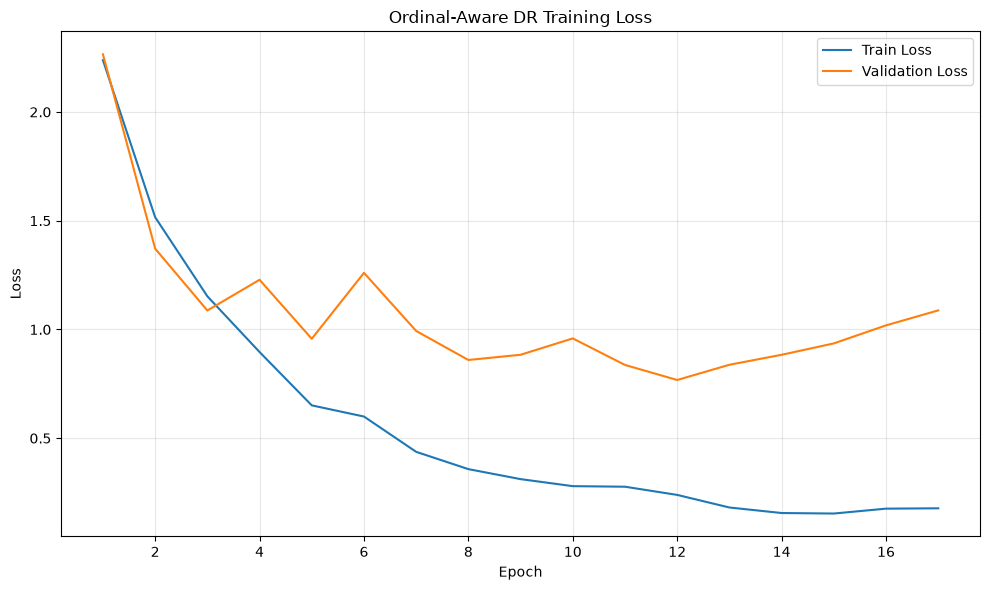

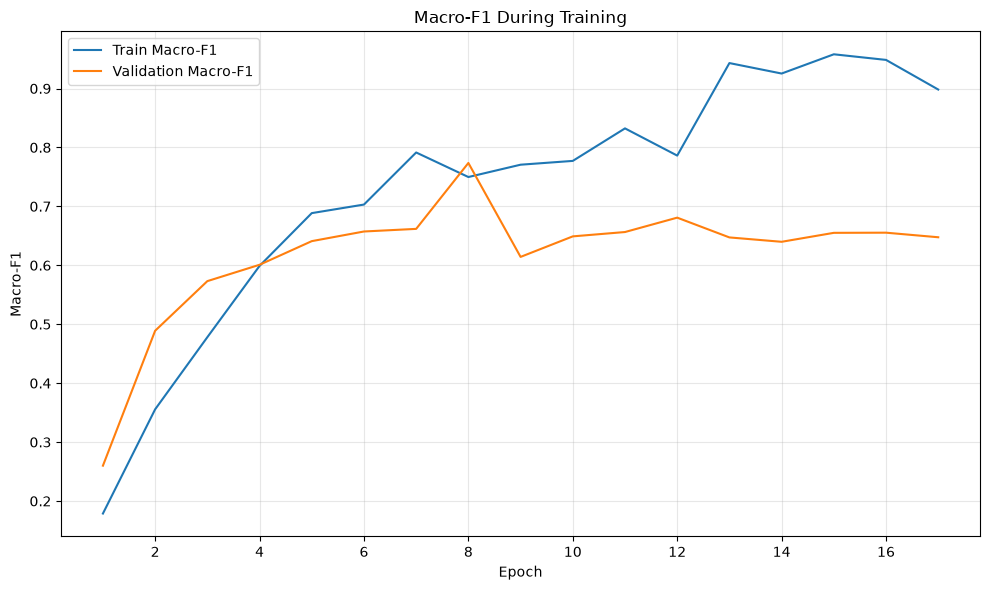

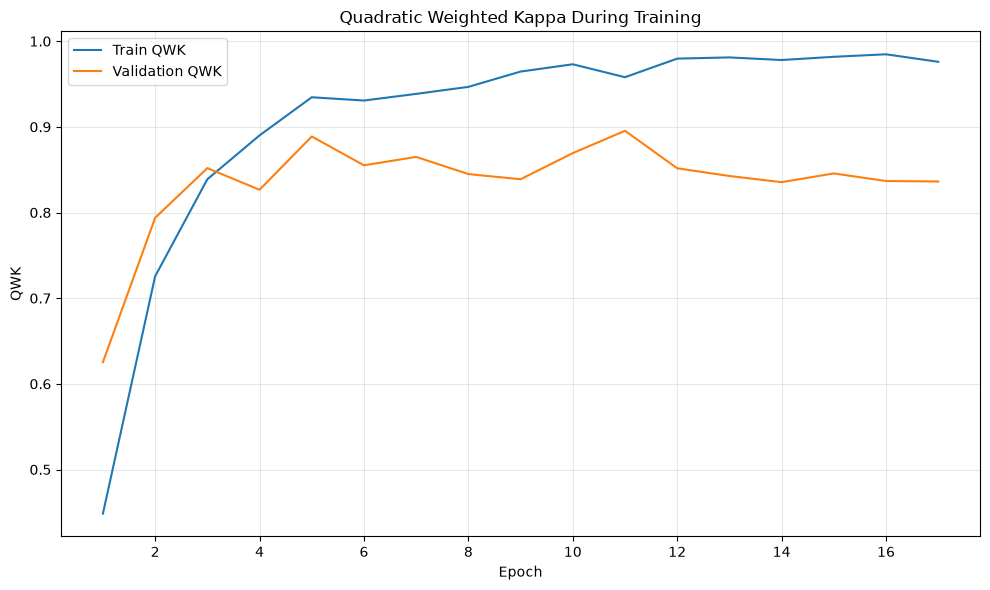

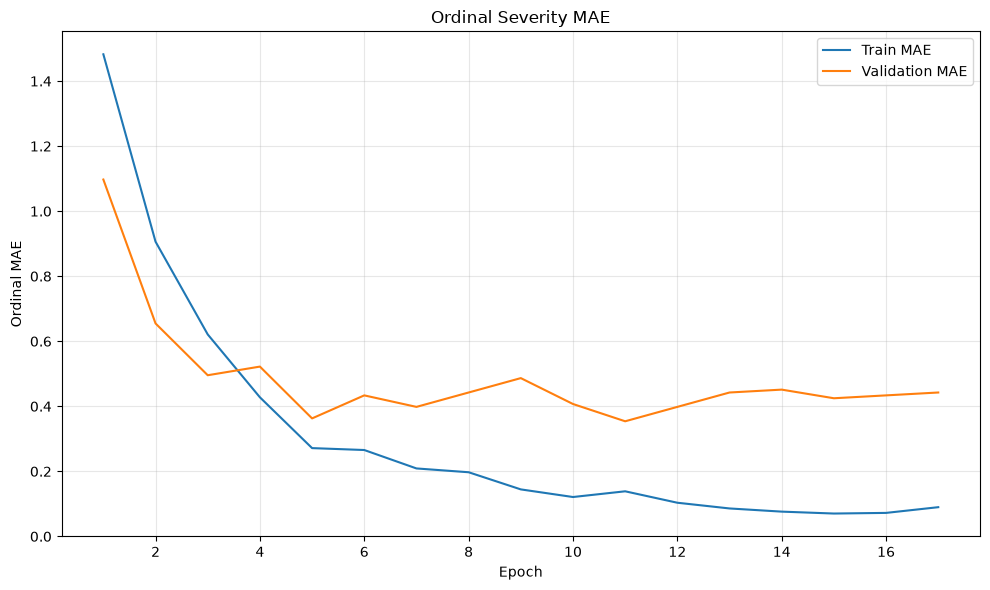


GPU INFORMATION
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
CUDA: 13.2
Peak GPU memory: 4.11 GB

CELL 4 COMPLETED SUCCESSFULLY.


In [10]:
# ============================================================
# CELL 4
# ORDINAL-AWARE DR TRAINING
# SELF-CONTAINED TRAINING CELL
# ============================================================

import time
import copy
import gc
from pathlib import Path

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    cohen_kappa_score,
    mean_absolute_error,
    confusion_matrix
)

# ============================================================
# OUTPUT DIRECTORIES
# ============================================================

PROJECT_ROOT = DATASET_ROOT.parent

OUTPUT_DIR = PROJECT_ROOT / "ordinal_dr_results"

MODEL_DIR = OUTPUT_DIR / "models"

FIGURE_DIR = OUTPUT_DIR / "figures"

RESULTS_DIR = OUTPUT_DIR / "results"

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("=" * 75)
print("OUTPUT DIRECTORIES")
print("=" * 75)

print("Output :", OUTPUT_DIR)
print("Models :", MODEL_DIR)
print("Figures:", FIGURE_DIR)
print("Results:", RESULTS_DIR)


# ============================================================
# TRAINING CONFIGURATION
# ============================================================

EPOCHS = 20

LEARNING_RATE = 3e-4

WEIGHT_DECAY = 1e-4

GRADIENT_CLIP = 1.0

PATIENCE = 6

MIN_DELTA = 1e-4


# ============================================================
# AMP / MIXED PRECISION
# ============================================================

USE_AMP = torch.cuda.is_available()

if USE_AMP:

    scaler = torch.amp.GradScaler(
        "cuda"
    )

else:

    scaler = None


# ============================================================
# MODEL SAVE PATHS
# ============================================================

BEST_MODEL_PATH = (
    MODEL_DIR /
    "best_ordinal_dr_model.pth"
)

LAST_MODEL_PATH = (
    MODEL_DIR /
    "last_ordinal_dr_model.pth"
)

HISTORY_PATH = (
    RESULTS_DIR /
    "training_history.csv"
)


# ============================================================
# OPTIMIZER
# ============================================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)


# ============================================================
# LEARNING RATE SCHEDULER
# ============================================================

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
    eta_min=1e-6
)


# ============================================================
# METRIC FUNCTION
# ============================================================

def calculate_metrics(
    y_true,
    y_pred
):

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    balanced_acc = balanced_accuracy_score(
        y_true,
        y_pred
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    weighted_f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    qwk = cohen_kappa_score(
        y_true,
        y_pred,
        weights="quadratic"
    )

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    return {
        "accuracy": accuracy,
        "balanced_accuracy": balanced_acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "qwk": qwk,
        "mae": mae
    }


# ============================================================
# TRAIN ONE EPOCH
# ============================================================

def train_one_epoch():

    model.train()

    running_total = 0.0
    running_cls = 0.0
    running_ord = 0.0
    running_focal = 0.0

    all_targets = []
    all_predictions = []

    start_time = time.time()

    for batch_idx, (
        images,
        labels
    ) in enumerate(train_loader):

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        if torch.cuda.is_available():

            images = images.contiguous(
                memory_format=torch.channels_last
            )

        optimizer.zero_grad(
            set_to_none=True
        )

        # ----------------------------------------------------
        # FORWARD
        # ----------------------------------------------------

        if USE_AMP:

            with torch.autocast(
                device_type="cuda",
                dtype=torch.float16
            ):

                outputs = model(
                    images
                )

                losses = criterion(
                    outputs,
                    labels
                )

                loss = losses["total"]

        else:

            outputs = model(
                images
            )

            losses = criterion(
                outputs,
                labels
            )

            loss = losses["total"]

        # ----------------------------------------------------
        # BACKPROPAGATION
        # ----------------------------------------------------

        if USE_AMP:

            scaler.scale(
                loss
            ).backward()

            scaler.unscale_(
                optimizer
            )

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                GRADIENT_CLIP
            )

            scaler.step(
                optimizer
            )

            scaler.update()

        else:

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                GRADIENT_CLIP
            )

            optimizer.step()

        # ----------------------------------------------------
        # LOSSES
        # ----------------------------------------------------

        running_total += (
            losses["total"].item()
        )

        running_cls += (
            losses["classification"].item()
        )

        running_ord += (
            losses["ordinal"].item()
        )

        running_focal += (
            losses["focal"].item()
        )

        # ----------------------------------------------------
        # ORDINAL PREDICTION
        # ----------------------------------------------------

        with torch.no_grad():

            predictions = ordinal_prediction(
                outputs["ordinal_logits"]
            )

        all_targets.extend(
            labels.detach().cpu().numpy()
        )

        all_predictions.extend(
            predictions.detach().cpu().numpy()
        )

        # ----------------------------------------------------
        # PROGRESS
        # ----------------------------------------------------

        print(
            f"\rBatch "
            f"{batch_idx + 1:02d}/"
            f"{len(train_loader):02d} | "
            f"Loss: {loss.item():.4f}",
            end=""
        )

    print()

    # --------------------------------------------------------
    # METRICS
    # --------------------------------------------------------

    metrics = calculate_metrics(
        all_targets,
        all_predictions
    )

    elapsed = (
        time.time()
        - start_time
    )

    num_batches = len(
        train_loader
    )

    return {

        "loss":
            running_total / num_batches,

        "classification_loss":
            running_cls / num_batches,

        "ordinal_loss":
            running_ord / num_batches,

        "focal_loss":
            running_focal / num_batches,

        **metrics,

        "time":
            elapsed
    }


# ============================================================
# VALIDATION
# ============================================================

@torch.no_grad()
def validate():

    model.eval()

    running_total = 0.0
    running_cls = 0.0
    running_ord = 0.0
    running_focal = 0.0

    all_targets = []
    all_predictions = []

    for images, labels in val_loader:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        if torch.cuda.is_available():

            images = images.contiguous(
                memory_format=torch.channels_last
            )

        if USE_AMP:

            with torch.autocast(
                device_type="cuda",
                dtype=torch.float16
            ):

                outputs = model(
                    images
                )

                losses = criterion(
                    outputs,
                    labels
                )

        else:

            outputs = model(
                images
            )

            losses = criterion(
                outputs,
                labels
            )

        running_total += (
            losses["total"].item()
        )

        running_cls += (
            losses["classification"].item()
        )

        running_ord += (
            losses["ordinal"].item()
        )

        running_focal += (
            losses["focal"].item()
        )

        predictions = ordinal_prediction(
            outputs["ordinal_logits"]
        )

        all_targets.extend(
            labels.cpu().numpy()
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

    metrics = calculate_metrics(
        all_targets,
        all_predictions
    )

    num_batches = len(
        val_loader
    )

    return {

        "loss":
            running_total / num_batches,

        "classification_loss":
            running_cls / num_batches,

        "ordinal_loss":
            running_ord / num_batches,

        "focal_loss":
            running_focal / num_batches,

        **metrics
    }


# ============================================================
# HISTORY
# ============================================================

history = {

    "epoch": [],

    "train_loss": [],
    "val_loss": [],

    "train_cls_loss": [],
    "val_cls_loss": [],

    "train_ord_loss": [],
    "val_ord_loss": [],

    "train_accuracy": [],
    "val_accuracy": [],

    "train_balanced_accuracy": [],
    "val_balanced_accuracy": [],

    "train_macro_f1": [],
    "val_macro_f1": [],

    "train_weighted_f1": [],
    "val_weighted_f1": [],

    "train_qwk": [],
    "val_qwk": [],

    "train_mae": [],
    "val_mae": [],

    "learning_rate": [],

    "epoch_time": [],

    "gpu_memory_gb": []
}


# ============================================================
# BEST MODEL
# ============================================================

best_qwk = -np.inf

best_epoch = 0

patience_counter = 0

best_state = None


# ============================================================
# TRAINING START
# ============================================================

print("\n" + "=" * 90)
print("STARTING ORDINAL-AWARE DR TRAINING")
print("=" * 90)

print(
    f"Device        : {DEVICE}"
)

print(
    f"GPU           : "
    f"{torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}"
)

print(
    f"Epochs        : {EPOCHS}"
)

print(
    f"Batch size    : {BATCH_SIZE}"
)

print(
    f"Image size    : {IMAGE_SIZE} × {IMAGE_SIZE}"
)

print(
    f"Learning rate : {LEARNING_RATE}"
)

print(
    f"AMP           : {USE_AMP}"
)

print(
    f"Train images  : {len(train_dataset)}"
)

print(
    f"Validation    : {len(val_dataset)}"
)

print("=" * 90)


# ============================================================
# TRAINING LOOP
# ============================================================

training_start = time.time()

for epoch in range(
    1,
    EPOCHS + 1
):

    epoch_start = time.time()

    print(
        f"\n{'=' * 90}"
    )

    print(
        f"EPOCH {epoch}/{EPOCHS}"
    )

    print(
        f"{'=' * 90}"
    )

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    train_metrics = train_one_epoch()

    # --------------------------------------------------------
    # VALIDATE
    # --------------------------------------------------------

    val_metrics = validate()

    # --------------------------------------------------------
    # LEARNING RATE
    # --------------------------------------------------------

    current_lr = (
        optimizer.param_groups[0]["lr"]
    )

    scheduler.step()

    # --------------------------------------------------------
    # GPU MEMORY
    # --------------------------------------------------------

    if torch.cuda.is_available():

        torch.cuda.synchronize()

        gpu_memory = (
            torch.cuda.max_memory_allocated()
            /
            (1024 ** 3)
        )

        torch.cuda.reset_peak_memory_stats()

    else:

        gpu_memory = 0.0

    # --------------------------------------------------------
    # TIME
    # --------------------------------------------------------

    epoch_time = (
        time.time()
        - epoch_start
    )

    # ========================================================
    # STORE HISTORY
    # ========================================================

    history["epoch"].append(epoch)

    history["train_loss"].append(
        train_metrics["loss"]
    )

    history["val_loss"].append(
        val_metrics["loss"]
    )

    history["train_cls_loss"].append(
        train_metrics["classification_loss"]
    )

    history["val_cls_loss"].append(
        val_metrics["classification_loss"]
    )

    history["train_ord_loss"].append(
        train_metrics["ordinal_loss"]
    )

    history["val_ord_loss"].append(
        val_metrics["ordinal_loss"]
    )

    history["train_accuracy"].append(
        train_metrics["accuracy"]
    )

    history["val_accuracy"].append(
        val_metrics["accuracy"]
    )

    history["train_balanced_accuracy"].append(
        train_metrics["balanced_accuracy"]
    )

    history["val_balanced_accuracy"].append(
        val_metrics["balanced_accuracy"]
    )

    history["train_macro_f1"].append(
        train_metrics["macro_f1"]
    )

    history["val_macro_f1"].append(
        val_metrics["macro_f1"]
    )

    history["train_weighted_f1"].append(
        train_metrics["weighted_f1"]
    )

    history["val_weighted_f1"].append(
        val_metrics["weighted_f1"]
    )

    history["train_qwk"].append(
        train_metrics["qwk"]
    )

    history["val_qwk"].append(
        val_metrics["qwk"]
    )

    history["train_mae"].append(
        train_metrics["mae"]
    )

    history["val_mae"].append(
        val_metrics["mae"]
    )

    history["learning_rate"].append(
        current_lr
    )

    history["epoch_time"].append(
        epoch_time
    )

    history["gpu_memory_gb"].append(
        gpu_memory
    )

    # ========================================================
    # RESULTS
    # ========================================================

    print(
        "\nTRAIN | "
        f"Loss: {train_metrics['loss']:.4f} | "
        f"Acc: {train_metrics['accuracy']:.4f} | "
        f"BalAcc: {train_metrics['balanced_accuracy']:.4f} | "
        f"Macro-F1: {train_metrics['macro_f1']:.4f} | "
        f"QWK: {train_metrics['qwk']:.4f} | "
        f"MAE: {train_metrics['mae']:.4f}"
    )

    print(
        "VAL   | "
        f"Loss: {val_metrics['loss']:.4f} | "
        f"Acc: {val_metrics['accuracy']:.4f} | "
        f"BalAcc: {val_metrics['balanced_accuracy']:.4f} | "
        f"Macro-F1: {val_metrics['macro_f1']:.4f} | "
        f"QWK: {val_metrics['qwk']:.4f} | "
        f"MAE: {val_metrics['mae']:.4f}"
    )

    print(
        "LOSS  | "
        f"Cls: "
        f"{train_metrics['classification_loss']:.4f} → "
        f"{val_metrics['classification_loss']:.4f} | "
        f"Ord: "
        f"{train_metrics['ordinal_loss']:.4f} → "
        f"{val_metrics['ordinal_loss']:.4f}"
    )

    print(
        f"LR: {current_lr:.7f} | "
        f"GPU peak: {gpu_memory:.2f} GB | "
        f"Time: {epoch_time:.1f}s"
    )

    # ========================================================
    # BEST MODEL BASED ON VALIDATION QWK
    # ========================================================

    if (
        val_metrics["qwk"]
        >
        best_qwk + MIN_DELTA
    ):

        best_qwk = (
            val_metrics["qwk"]
        )

        best_epoch = epoch

        patience_counter = 0

        best_state = copy.deepcopy(
            model.state_dict()
        )

        torch.save(

            {
                "epoch": epoch,

                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "scheduler_state_dict":
                    scheduler.state_dict(),

                "best_qwk":
                    best_qwk,

                "class_names":
                    CLASS_NAMES,

                "num_classes":
                    NUM_CLASSES,

                "image_size":
                    IMAGE_SIZE
            },

            BEST_MODEL_PATH
        )

        print(
            f"\n✓ BEST MODEL SAVED"
            f" | Validation QWK: "
            f"{best_qwk:.4f}"
        )

    else:

        patience_counter += 1

        print(
            f"\nNo QWK improvement "
            f"({patience_counter}/{PATIENCE})"
        )

    # ========================================================
    # SAVE LAST MODEL
    # ========================================================

    torch.save(

        {
            "epoch": epoch,

            "model_state_dict":
                model.state_dict(),

            "optimizer_state_dict":
                optimizer.state_dict(),

            "scheduler_state_dict":
                scheduler.state_dict(),

            "best_qwk":
                best_qwk,

            "class_names":
                CLASS_NAMES,

            "num_classes":
                NUM_CLASSES,

            "image_size":
                IMAGE_SIZE
        },

        LAST_MODEL_PATH
    )

    # ========================================================
    # SAVE HISTORY
    # ========================================================

    pd.DataFrame(
        history
    ).to_csv(
        HISTORY_PATH,
        index=False
    )

    # ========================================================
    # EARLY STOPPING
    # ========================================================

    if patience_counter >= PATIENCE:

        print(
            "\n"
            + "=" * 90
        )

        print(
            "EARLY STOPPING"
        )

        print(
            f"Best epoch: {best_epoch}"
        )

        print(
            f"Best QWK  : {best_qwk:.4f}"
        )

        print(
            "=" * 90
        )

        break


# ============================================================
# RESTORE BEST MODEL
# ============================================================

if best_state is not None:

    model.load_state_dict(
        best_state
    )


# ============================================================
# TRAINING SUMMARY
# ============================================================

total_training_time = (
    time.time()
    - training_start
)

print(
    "\n"
    + "=" * 90
)

print(
    "TRAINING COMPLETED"
)

print(
    "=" * 90
)

print(
    f"Best epoch          : {best_epoch}"
)

print(
    f"Best validation QWK: {best_qwk:.4f}"
)

print(
    f"Training time       : "
    f"{total_training_time / 60:.2f} minutes"
)

print(
    f"Best model          : "
    f"{BEST_MODEL_PATH}"
)

print(
    f"History             : "
    f"{HISTORY_PATH}"
)


# ============================================================
# TRAINING DATAFRAME
# ============================================================

history_df = pd.DataFrame(
    history
)


# ============================================================
# PLOT 1 — LOSS
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Train Loss"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Ordinal-Aware DR Training Loss"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR /
    "training_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# PLOT 2 — MACRO F1
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    history_df["epoch"],
    history_df["train_macro_f1"],
    label="Train Macro-F1"
)

plt.plot(
    history_df["epoch"],
    history_df["val_macro_f1"],
    label="Validation Macro-F1"
)

plt.xlabel("Epoch")
plt.ylabel("Macro-F1")

plt.title(
    "Macro-F1 During Training"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR /
    "macro_f1_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# PLOT 3 — QWK
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    history_df["epoch"],
    history_df["train_qwk"],
    label="Train QWK"
)

plt.plot(
    history_df["epoch"],
    history_df["val_qwk"],
    label="Validation QWK"
)

plt.xlabel("Epoch")
plt.ylabel("QWK")

plt.title(
    "Quadratic Weighted Kappa During Training"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR /
    "qwk_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# PLOT 4 — ORDINAL MAE
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    history_df["epoch"],
    history_df["train_mae"],
    label="Train MAE"
)

plt.plot(
    history_df["epoch"],
    history_df["val_mae"],
    label="Validation MAE"
)

plt.xlabel("Epoch")
plt.ylabel("Ordinal MAE")

plt.title(
    "Ordinal Severity MAE"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR /
    "ordinal_mae_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# GPU SUMMARY
# ============================================================

if torch.cuda.is_available():

    print(
        "\n"
        + "=" * 75
    )

    print(
        "GPU INFORMATION"
    )

    print(
        "=" * 75
    )

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

    print(
        "CUDA:",
        torch.version.cuda
    )

    print(
        "Peak GPU memory:",
        f"{max(history['gpu_memory_gb']):.2f} GB"
    )


print(
    "\nCELL 4 COMPLETED SUCCESSFULLY."
)

In [11]:
# ============================================================
# CELL 3 — PROPOSED ORDINAL-AWARE DR MODEL
# EfficientNet-B0 + Classification Head + Ordinal Head
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision.models import (
    efficientnet_b0,
    EfficientNet_B0_Weights
)

# ============================================================
# CONFIGURATION
# ============================================================

NUM_CLASSES = 7
NUM_THRESHOLDS = NUM_CLASSES - 1

CLASS_NAMES = [
    "No DR signs",
    "Mild NPDR",
    "Moderate NPDR",
    "Severe NPDR",
    "Very Severe NPDR",
    "PDR",
    "Advanced PDR"
]

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# Loss weights
LAMBDA_CLASSIFICATION = 1.0
LAMBDA_ORDINAL = 1.0
LAMBDA_FOCAL = 0.0


# ============================================================
# ORDINAL-AWARE EFFICIENTNET
# ============================================================

class OrdinalEfficientNet(nn.Module):

    def __init__(
        self,
        num_classes=7,
        pretrained=True
    ):

        super().__init__()

        # ----------------------------------------------------
        # EfficientNet-B0 backbone
        # ----------------------------------------------------

        if pretrained:

            weights = (
                EfficientNet_B0_Weights.DEFAULT
            )

        else:

            weights = None

        backbone = efficientnet_b0(
            weights=weights
        )

        # EfficientNet-B0 classifier input = 1280
        feature_dim = (
            backbone.classifier[1].in_features
        )

        # Remove original classifier
        backbone.classifier = nn.Identity()

        self.backbone = backbone

        self.feature_dim = feature_dim

        # ----------------------------------------------------
        # Feature projection
        # 1280 → 512
        # ----------------------------------------------------

        self.feature_projection = nn.Sequential(

            nn.Linear(
                feature_dim,
                512
            ),

            nn.BatchNorm1d(
                512
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Dropout(
                p=0.30
            )
        )

        # ----------------------------------------------------
        # Conventional classification head
        # ----------------------------------------------------

        self.classification_head = nn.Sequential(

            nn.Linear(
                512,
                256
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Dropout(
                p=0.25
            ),

            nn.Linear(
                256,
                num_classes
            )
        )

        # ----------------------------------------------------
        # Ordinal head
        #
        # Six outputs for seven ordered classes
        #
        # output[i] = P(Y > i)
        # ----------------------------------------------------

        self.ordinal_head = nn.Sequential(

            nn.Linear(
                512,
                256
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Dropout(
                p=0.25
            ),

            nn.Linear(
                256,
                num_classes - 1
            )
        )

        # ----------------------------------------------------
        # Initialize newly created layers
        # ----------------------------------------------------

        self._initialize_heads()


    def _initialize_heads(self):

        for module in [

            self.feature_projection,

            self.classification_head,

            self.ordinal_head

        ]:

            for layer in module:

                if isinstance(
                    layer,
                    nn.Linear
                ):

                    nn.init.kaiming_normal_(
                        layer.weight,
                        nonlinearity="relu"
                    )

                    if layer.bias is not None:

                        nn.init.zeros_(
                            layer.bias
                        )


    # ========================================================
    # FORWARD
    # ========================================================

    def forward(
        self,
        x
    ):

        # ----------------------------------------------------
        # Backbone
        # ----------------------------------------------------

        features = self.backbone(
            x
        )

        # ----------------------------------------------------
        # 1280 → 512
        # ----------------------------------------------------

        features = self.feature_projection(
            features
        )

        # ----------------------------------------------------
        # Classification branch
        # ----------------------------------------------------

        classification_logits = (
            self.classification_head(
                features
            )
        )

        # ----------------------------------------------------
        # Ordinal branch
        # ----------------------------------------------------

        ordinal_logits = (
            self.ordinal_head(
                features
            )
        )

        return {

            "features":
                features,

            "classification_logits":
                classification_logits,

            "ordinal_logits":
                ordinal_logits
        }


# ============================================================
# ORDINAL TARGET CREATION
# ============================================================

def create_ordinal_targets(
    labels,
    num_classes=NUM_CLASSES
):

    """
    Converts class labels into cumulative ordinal targets.

    Example:

    Class 0:
        [0, 0, 0, 0, 0, 0]

    Class 1:
        [1, 0, 0, 0, 0, 0]

    Class 2:
        [1, 1, 0, 0, 0, 0]

    Class 3:
        [1, 1, 1, 0, 0, 0]

    Class 6:
        [1, 1, 1, 1, 1, 1]
    """

    thresholds = torch.arange(
        num_classes - 1,
        device=labels.device
    ).unsqueeze(0)

    labels_expanded = labels.unsqueeze(1)

    ordinal_targets = (
        labels_expanded > thresholds
    ).float()

    return ordinal_targets


# ============================================================
# ORDINAL PREDICTION
# ============================================================

def ordinal_prediction(
    ordinal_logits
):

    """
    Converts six ordinal probabilities
    into a single severity level.

    Predicted class =
    number of thresholds passed.
    """

    probabilities = torch.sigmoid(
        ordinal_logits
    )

    predictions = (
        probabilities > 0.5
    ).sum(
        dim=1
    )

    return predictions.long()


# ============================================================
# ORDINAL LOSS
# ============================================================

class OrdinalLoss(nn.Module):

    def __init__(
        self,
        weight=None
    ):

        super().__init__()

        self.weight = weight


    def forward(
        self,
        ordinal_logits,
        labels
    ):

        targets = create_ordinal_targets(
            labels
        )

        loss = F.binary_cross_entropy_with_logits(
            ordinal_logits,
            targets,
            weight=self.weight
        )

        return loss


# ============================================================
# FOCAL LOSS
# ============================================================

class FocalLoss(nn.Module):

    def __init__(
        self,
        alpha=None,
        gamma=2.0
    ):

        super().__init__()

        self.alpha = alpha
        self.gamma = gamma


    def forward(
        self,
        logits,
        targets
    ):

        ce_loss = F.cross_entropy(
            logits,
            targets,
            weight=self.alpha,
            reduction="none"
        )

        pt = torch.exp(
            -ce_loss
        )

        focal_loss = (
            (1 - pt) ** self.gamma
            * ce_loss
        )

        return focal_loss.mean()


# ============================================================
# COMBINED RESEARCH LOSS
# ============================================================

class OrdinalCombinedLoss(nn.Module):

    def __init__(
        self,
        class_weights=None,
        lambda_classification=1.0,
        lambda_ordinal=1.0,
        lambda_focal=0.0
    ):

        super().__init__()

        self.lambda_classification = (
            lambda_classification
        )

        self.lambda_ordinal = (
            lambda_ordinal
        )

        self.lambda_focal = (
            lambda_focal
        )

        # Classification loss
        self.classification_loss = (
            nn.CrossEntropyLoss(
                weight=class_weights
            )
        )

        # Ordinal loss
        self.ordinal_loss = (
            OrdinalLoss()
        )

        # Focal loss
        self.focal_loss = (
            FocalLoss(
                alpha=class_weights,
                gamma=2.0
            )
        )


    def forward(
        self,
        outputs,
        labels
    ):

        # ----------------------------------------------------
        # Classification
        # ----------------------------------------------------

        classification_loss = (
            self.classification_loss(
                outputs[
                    "classification_logits"
                ],
                labels
            )
        )

        # ----------------------------------------------------
        # Ordinal
        # ----------------------------------------------------

        ordinal_loss = (
            self.ordinal_loss(
                outputs[
                    "ordinal_logits"
                ],
                labels
            )
        )

        # ----------------------------------------------------
        # Focal
        # ----------------------------------------------------

        focal_loss = (
            self.focal_loss(
                outputs[
                    "classification_logits"
                ],
                labels
            )
        )

        # ----------------------------------------------------
        # Combined objective
        # ----------------------------------------------------

        total_loss = (

            self.lambda_classification
            * classification_loss

            +

            self.lambda_ordinal
            * ordinal_loss

            +

            self.lambda_focal
            * focal_loss
        )

        return {

            "total":
                total_loss,

            "classification":
                classification_loss,

            "ordinal":
                ordinal_loss,

            "focal":
                focal_loss
        }


# ============================================================
# CREATE MODEL
# ============================================================

model = OrdinalEfficientNet(
    num_classes=NUM_CLASSES,
    pretrained=True
)


# ============================================================
# MOVE TO GPU
# ============================================================

model = model.to(
    DEVICE
)


# ============================================================
# CHANNELS-LAST FOR NVIDIA GPU
# ============================================================

if torch.cuda.is_available():

    model = model.to(
        memory_format=torch.channels_last
    )


# ============================================================
# CLASS WEIGHTS
# ============================================================

# These should already exist from Cell 2.
# If available, move them to GPU.

if "class_weights" in globals():

    class_weights_gpu = (
        class_weights.to(DEVICE)
    )

else:

    class_weights_gpu = None


# ============================================================
# CREATE LOSS
# ============================================================

criterion = OrdinalCombinedLoss(

    class_weights=class_weights_gpu,

    lambda_classification=
        LAMBDA_CLASSIFICATION,

    lambda_ordinal=
        LAMBDA_ORDINAL,

    lambda_focal=
        LAMBDA_FOCAL
)


criterion = criterion.to(
    DEVICE
)


# ============================================================
# MODEL INFORMATION
# ============================================================

total_parameters = sum(
    p.numel()
    for p in model.parameters()
)

trainable_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


print()
print("=" * 75)
print("PROPOSED ORDINAL-AWARE DR MODEL")
print("=" * 75)

print(
    "Backbone             : EfficientNet-B0"
)

print(
    "Pretrained           : ImageNet"
)

print(
    "Feature dimension    : 512"
)

print(
    "Classification head  : 7 outputs"
)

print(
    "Ordinal head         : 6 thresholds"
)

print(
    "Total parameters     : "
    f"{total_parameters:,}"
)

print(
    "Trainable parameters : "
    f"{trainable_parameters:,}"
)

print(
    "Device               : "
    f"{DEVICE}"
)

print()
print("LOSS CONFIGURATION")

print(
    f"Classification weight: "
    f"{LAMBDA_CLASSIFICATION}"
)

print(
    f"Ordinal weight       : "
    f"{LAMBDA_ORDINAL}"
)

print(
    f"Focal weight         : "
    f"{LAMBDA_FOCAL}"
)

print()
print("ORDINAL STRUCTURE")

for i in range(NUM_THRESHOLDS):

    print(
        f"Threshold {i + 1}: "
        f"P(Y > {i})"
    )


# ============================================================
# FORWARD-PASS TEST
# ============================================================

print()
print("=" * 75)
print("TESTING FORWARD PASS")
print("=" * 75)

model.eval()

with torch.no_grad():

    dummy_images = torch.randn(
        2,
        3,
        IMAGE_SIZE,
        IMAGE_SIZE,
        device=DEVICE
    )

    if torch.cuda.is_available():

        dummy_images = dummy_images.contiguous(
            memory_format=torch.channels_last
        )

    outputs = model(
        dummy_images
    )


print(
    "Input shape          : "
    f"{dummy_images.shape}"
)

print(
    "Feature shape        : "
    f"{outputs['features'].shape}"
)

print(
    "Classification shape : "
    f"{outputs['classification_logits'].shape}"
)

print(
    "Ordinal shape        : "
    f"{outputs['ordinal_logits'].shape}"
)


# ============================================================
# TEST ORDINAL PREDICTION
# ============================================================

test_predictions = ordinal_prediction(
    outputs["ordinal_logits"]
)

print(
    "Ordinal predictions  : "
    f"{test_predictions.tolist()}"
)


# ============================================================
# GPU MEMORY
# ============================================================

if torch.cuda.is_available():

    allocated = (
        torch.cuda.memory_allocated()
        / (1024 ** 3)
    )

    reserved = (
        torch.cuda.memory_reserved()
        / (1024 ** 3)
    )

    print()
    print(
        f"GPU allocated        : "
        f"{allocated:.2f} GB"
    )

    print(
        f"GPU reserved         : "
        f"{reserved:.2f} GB"
    )


print()
print("=" * 75)
print("MODEL CREATED SUCCESSFULLY")
print("=" * 75)


PROPOSED ORDINAL-AWARE DR MODEL
Backbone             : EfficientNet-B0
Pretrained           : ImageNet
Feature dimension    : 512
Classification head  : 7 outputs
Ordinal head         : 6 thresholds
Total parameters     : 4,930,441
Trainable parameters : 4,930,441
Device               : cuda

LOSS CONFIGURATION
Classification weight: 1.0
Ordinal weight       : 1.0
Focal weight         : 0.0

ORDINAL STRUCTURE
Threshold 1: P(Y > 0)
Threshold 2: P(Y > 1)
Threshold 3: P(Y > 2)
Threshold 4: P(Y > 3)
Threshold 5: P(Y > 4)
Threshold 6: P(Y > 5)

TESTING FORWARD PASS
Input shape          : torch.Size([2, 3, 384, 384])
Feature shape        : torch.Size([2, 512])
Classification shape : torch.Size([2, 7])
Ordinal shape        : torch.Size([2, 6])
Ordinal predictions  : [2, 2]

GPU allocated        : 0.18 GB
GPU reserved         : 0.22 GB

MODEL CREATED SUCCESSFULLY



STARTING PROPOSED ORDINAL-AWARE DR TRAINING
GPU            : NVIDIA GeForce RTX 4050 Laptop GPU
Epochs         : 20
Batch size     : 32
Image size     : 384 × 384
Learning rate  : 0.0003
Weight decay   : 0.0001
AMP            : True
Train images   : 530
Validation     : 113
Model          : EfficientNet-B0 + Ordinal Head
Selection      : Best Validation QWK

EPOCH 1/20
Batch 16/16 | Loss: 1.9846

TRAIN | Loss 2.5882 | Acc 0.1582 | BalAcc 0.1353 | Macro-F1 0.1031 | QWK 0.1651 | MAE 1.7559
VAL   | Loss 2.5449 | Acc 0.2212 | BalAcc 0.1925 | Macro-F1 0.1197 | QWK 0.3339 | MAE 1.4690
LOSS  | Cls 1.9295 → 2.0001 | Ord 0.6587 → 0.5449
LR 0.0003000 | GPU 4.10 GB | Time 70.8s

✓ BEST MODEL SAVED | QWK = 0.3339

EPOCH 2/20
Batch 16/16 | Loss: 1.3927

TRAIN | Loss 1.9652 | Acc 0.2891 | BalAcc 0.3098 | Macro-F1 0.2308 | QWK 0.5314 | MAE 1.2520
VAL   | Loss 2.0739 | Acc 0.4867 | BalAcc 0.5133 | Macro-F1 0.3840 | QWK 0.7718 | MAE 0.8053
LOSS  | Cls 1.4880 → 1.7169 | Ord 0.4772 → 0.3571
LR 0.0002982

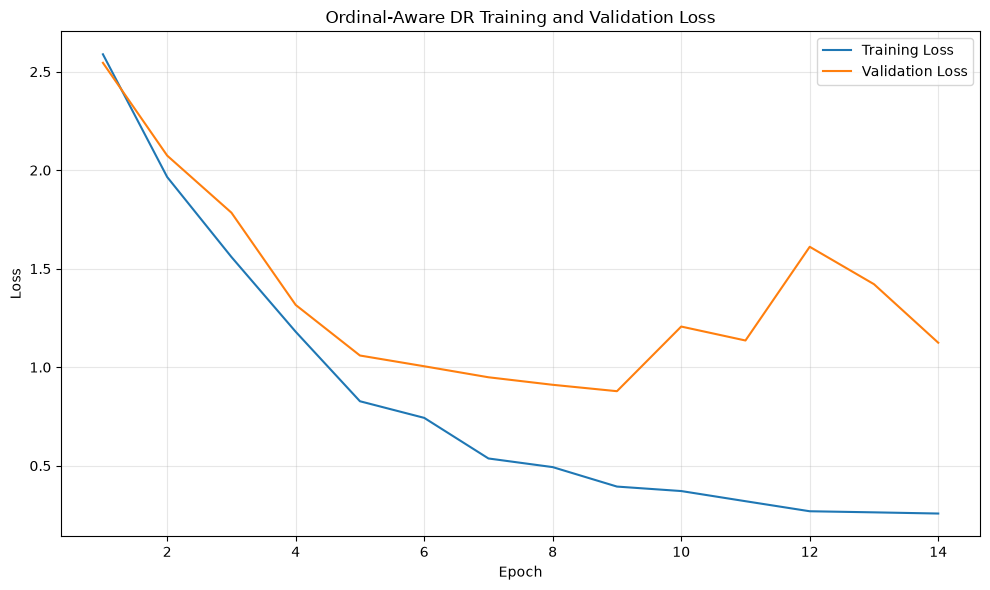

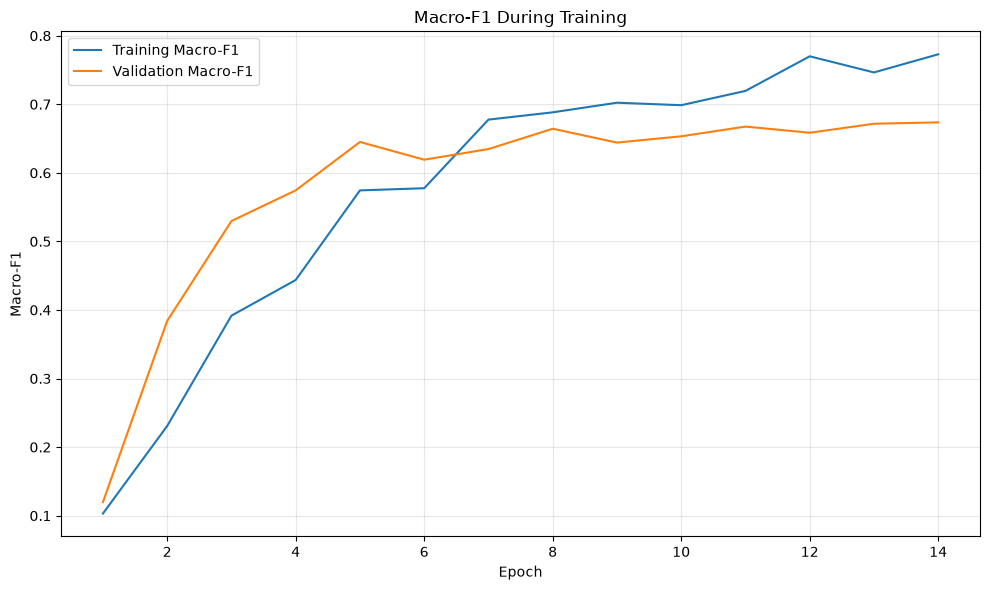

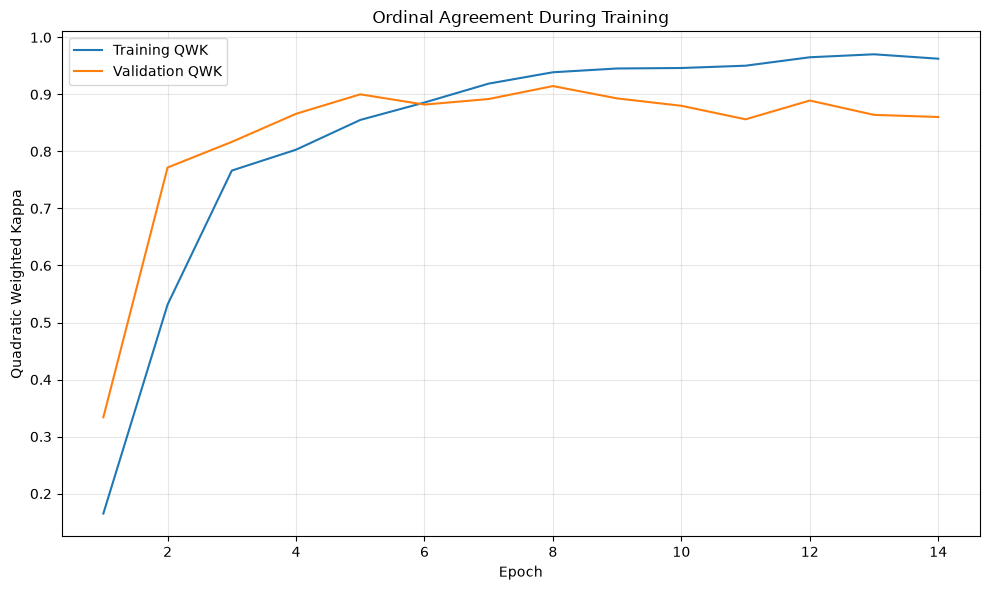

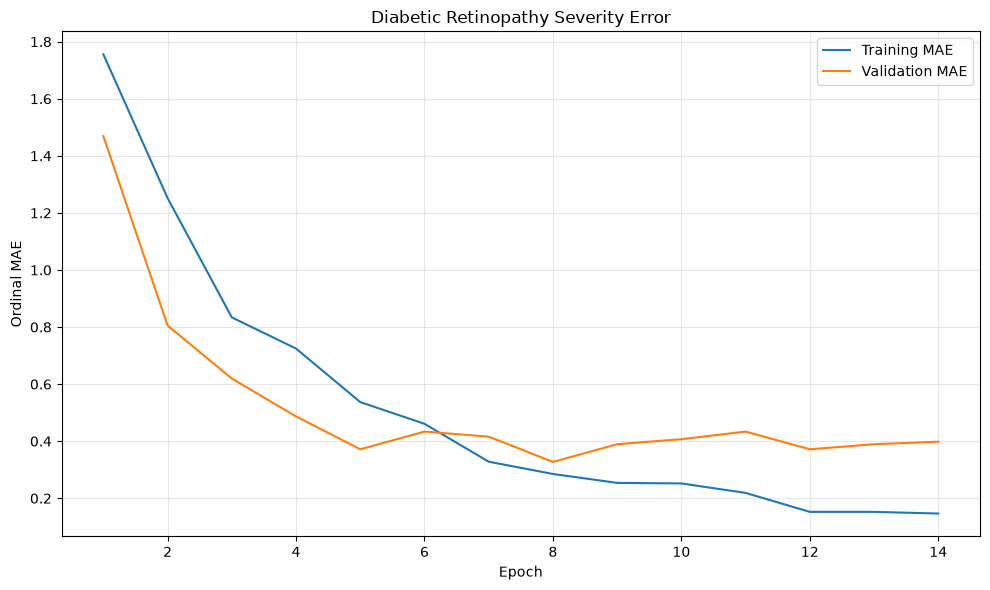


GPU TRAINING SUMMARY
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
CUDA: 13.2
Maximum GPU memory used: 4.12 GB

CELL 4 COMPLETED SUCCESSFULLY.


In [12]:
# ============================================================
# CELL 4 — TRAIN PROPOSED ORDINAL-AWARE DR MODEL
# ============================================================

import time
import copy
import gc
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
    mean_absolute_error
)

# ============================================================
# REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():

    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# ============================================================
# OUTPUT DIRECTORIES
# ============================================================

PROJECT_ROOT = DATASET_ROOT.parent

OUTPUT_DIR = (
    PROJECT_ROOT /
    "ordinal_dr_results"
)

MODEL_DIR = (
    OUTPUT_DIR /
    "models"
)

FIGURE_DIR = (
    OUTPUT_DIR /
    "figures"
)

RESULTS_DIR = (
    OUTPUT_DIR /
    "results"
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# ============================================================
# TRAINING CONFIGURATION
# ============================================================

EPOCHS = 20

LEARNING_RATE = 3e-4

WEIGHT_DECAY = 1e-4

PATIENCE = 6

MIN_DELTA = 1e-4

GRADIENT_CLIP = 1.0

# ============================================================
# MIXED PRECISION
# ============================================================

USE_AMP = torch.cuda.is_available()

if USE_AMP:

    scaler = torch.amp.GradScaler(
        "cuda"
    )

else:

    scaler = None

# ============================================================
# MODEL PATHS
# ============================================================

BEST_MODEL_PATH = (
    MODEL_DIR /
    "best_ordinal_efficientnet_b0.pth"
)

LAST_MODEL_PATH = (
    MODEL_DIR /
    "last_ordinal_efficientnet_b0.pth"
)

HISTORY_PATH = (
    RESULTS_DIR /
    "ordinal_training_history.csv"
)

# ============================================================
# OPTIMIZER
# ============================================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# ============================================================
# SCHEDULER
# ============================================================

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
    eta_min=1e-6
)

# ============================================================
# METRICS
# ============================================================

def calculate_metrics(
    y_true,
    y_pred
):

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    balanced_accuracy = (
        balanced_accuracy_score(
            y_true,
            y_pred
        )
    )

    precision = precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    weighted_f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    qwk = cohen_kappa_score(
        y_true,
        y_pred,
        weights="quadratic"
    )

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    return {

        "accuracy":
            accuracy,

        "balanced_accuracy":
            balanced_accuracy,

        "precision":
            precision,

        "recall":
            recall,

        "macro_f1":
            macro_f1,

        "weighted_f1":
            weighted_f1,

        "qwk":
            qwk,

        "mae":
            mae
    }


# ============================================================
# TRAIN FUNCTION
# ============================================================

def train_one_epoch():

    model.train()

    total_loss = 0.0
    cls_loss_total = 0.0
    ord_loss_total = 0.0
    focal_loss_total = 0.0

    y_true = []
    y_pred = []

    start_time = time.time()

    for batch_idx, (
        images,
        labels
    ) in enumerate(train_loader):

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        if torch.cuda.is_available():

            images = images.contiguous(
                memory_format=torch.channels_last
            )

        optimizer.zero_grad(
            set_to_none=True
        )

        # ----------------------------------------------------
        # FORWARD
        # ----------------------------------------------------

        if USE_AMP:

            with torch.autocast(
                device_type="cuda",
                dtype=torch.float16
            ):

                outputs = model(
                    images
                )

                losses = criterion(
                    outputs,
                    labels
                )

                loss = losses["total"]

        else:

            outputs = model(
                images
            )

            losses = criterion(
                outputs,
                labels
            )

            loss = losses["total"]

        # ----------------------------------------------------
        # BACKPROPAGATION
        # ----------------------------------------------------

        if USE_AMP:

            scaler.scale(
                loss
            ).backward()

            scaler.unscale_(
                optimizer
            )

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                GRADIENT_CLIP
            )

            scaler.step(
                optimizer
            )

            scaler.update()

        else:

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                GRADIENT_CLIP
            )

            optimizer.step()

        # ----------------------------------------------------
        # LOSSES
        # ----------------------------------------------------

        total_loss += (
            losses["total"].item()
        )

        cls_loss_total += (
            losses["classification"].item()
        )

        ord_loss_total += (
            losses["ordinal"].item()
        )

        focal_loss_total += (
            losses["focal"].item()
        )

        # ----------------------------------------------------
        # ORDINAL PREDICTION
        # ----------------------------------------------------

        with torch.no_grad():

            predictions = ordinal_prediction(
                outputs[
                    "ordinal_logits"
                ]
            )

        y_true.extend(
            labels.detach()
            .cpu()
            .numpy()
        )

        y_pred.extend(
            predictions.detach()
            .cpu()
            .numpy()
        )

        print(
            f"\rBatch "
            f"{batch_idx + 1:02d}/"
            f"{len(train_loader):02d} "
            f"| Loss: {loss.item():.4f}",
            end=""
        )

    print()

    metrics = calculate_metrics(
        y_true,
        y_pred
    )

    n = len(
        train_loader
    )

    return {

        "loss":
            total_loss / n,

        "classification_loss":
            cls_loss_total / n,

        "ordinal_loss":
            ord_loss_total / n,

        "focal_loss":
            focal_loss_total / n,

        **metrics,

        "time":
            time.time() - start_time
    }


# ============================================================
# VALIDATION
# ============================================================

@torch.no_grad()
def validate():

    model.eval()

    total_loss = 0.0
    cls_loss_total = 0.0
    ord_loss_total = 0.0
    focal_loss_total = 0.0

    y_true = []
    y_pred = []

    for images, labels in val_loader:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        if torch.cuda.is_available():

            images = images.contiguous(
                memory_format=torch.channels_last
            )

        if USE_AMP:

            with torch.autocast(
                device_type="cuda",
                dtype=torch.float16
            ):

                outputs = model(
                    images
                )

                losses = criterion(
                    outputs,
                    labels
                )

        else:

            outputs = model(
                images
            )

            losses = criterion(
                outputs,
                labels
            )

        total_loss += (
            losses["total"].item()
        )

        cls_loss_total += (
            losses["classification"].item()
        )

        ord_loss_total += (
            losses["ordinal"].item()
        )

        focal_loss_total += (
            losses["focal"].item()
        )

        predictions = ordinal_prediction(
            outputs[
                "ordinal_logits"
            ]
        )

        y_true.extend(
            labels.cpu().numpy()
        )

        y_pred.extend(
            predictions.cpu().numpy()
        )

    metrics = calculate_metrics(
        y_true,
        y_pred
    )

    n = len(
        val_loader
    )

    return {

        "loss":
            total_loss / n,

        "classification_loss":
            cls_loss_total / n,

        "ordinal_loss":
            ord_loss_total / n,

        "focal_loss":
            focal_loss_total / n,

        **metrics
    }


# ============================================================
# HISTORY
# ============================================================

history = {

    "epoch": [],

    "train_loss": [],
    "val_loss": [],

    "train_accuracy": [],
    "val_accuracy": [],

    "train_balanced_accuracy": [],
    "val_balanced_accuracy": [],

    "train_precision": [],
    "val_precision": [],

    "train_recall": [],
    "val_recall": [],

    "train_macro_f1": [],
    "val_macro_f1": [],

    "train_weighted_f1": [],
    "val_weighted_f1": [],

    "train_qwk": [],
    "val_qwk": [],

    "train_mae": [],
    "val_mae": [],

    "train_cls_loss": [],
    "val_cls_loss": [],

    "train_ord_loss": [],
    "val_ord_loss": [],

    "learning_rate": [],

    "epoch_time": [],

    "gpu_memory_gb": []
}

# ============================================================
# BEST MODEL
# ============================================================

best_qwk = -np.inf

best_epoch = 0

patience_counter = 0

best_state = None

# ============================================================
# TRAINING
# ============================================================

print()
print("=" * 90)
print("STARTING PROPOSED ORDINAL-AWARE DR TRAINING")
print("=" * 90)

print(
    f"GPU            : "
    f"{torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}"
)

print(
    f"Epochs         : {EPOCHS}"
)

print(
    f"Batch size     : {BATCH_SIZE}"
)

print(
    f"Image size     : {IMAGE_SIZE} × {IMAGE_SIZE}"
)

print(
    f"Learning rate  : {LEARNING_RATE}"
)

print(
    f"Weight decay   : {WEIGHT_DECAY}"
)

print(
    f"AMP            : {USE_AMP}"
)

print(
    f"Train images   : {len(train_dataset)}"
)

print(
    f"Validation     : {len(val_dataset)}"
)

print(
    "Model          : EfficientNet-B0 + Ordinal Head"
)

print(
    "Selection      : Best Validation QWK"
)

print("=" * 90)


training_start = time.time()

for epoch in range(
    1,
    EPOCHS + 1
):

    epoch_start = time.time()

    print()
    print("=" * 90)

    print(
        f"EPOCH {epoch}/{EPOCHS}"
    )

    print("=" * 90)

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    train_metrics = train_one_epoch()

    # --------------------------------------------------------
    # VALIDATE
    # --------------------------------------------------------

    val_metrics = validate()

    # --------------------------------------------------------
    # CURRENT LR
    # --------------------------------------------------------

    current_lr = (
        optimizer.param_groups[0]["lr"]
    )

    scheduler.step()

    # --------------------------------------------------------
    # GPU MEMORY
    # --------------------------------------------------------

    if torch.cuda.is_available():

        torch.cuda.synchronize()

        gpu_memory = (
            torch.cuda.max_memory_allocated()
            /
            (1024 ** 3)
        )

        torch.cuda.reset_peak_memory_stats()

    else:

        gpu_memory = 0.0

    epoch_time = (
        time.time()
        - epoch_start
    )

    # ========================================================
    # HISTORY
    # ========================================================

    history["epoch"].append(
        epoch
    )

    for key in [
        "loss",
        "accuracy",
        "balanced_accuracy",
        "precision",
        "recall",
        "macro_f1",
        "weighted_f1",
        "qwk",
        "mae"
    ]:

        history[
            f"train_{key}"
        ].append(
            train_metrics[key]
        )

        history[
            f"val_{key}"
        ].append(
            val_metrics[key]
        )

    history["train_cls_loss"].append(
        train_metrics[
            "classification_loss"
        ]
    )

    history["val_cls_loss"].append(
        val_metrics[
            "classification_loss"
        ]
    )

    history["train_ord_loss"].append(
        train_metrics[
            "ordinal_loss"
        ]
    )

    history["val_ord_loss"].append(
        val_metrics[
            "ordinal_loss"
        ]
    )

    history["learning_rate"].append(
        current_lr
    )

    history["epoch_time"].append(
        epoch_time
    )

    history["gpu_memory_gb"].append(
        gpu_memory
    )

    # ========================================================
    # DISPLAY
    # ========================================================

    print()

    print(
        "TRAIN | "
        f"Loss {train_metrics['loss']:.4f} | "
        f"Acc {train_metrics['accuracy']:.4f} | "
        f"BalAcc {train_metrics['balanced_accuracy']:.4f} | "
        f"Macro-F1 {train_metrics['macro_f1']:.4f} | "
        f"QWK {train_metrics['qwk']:.4f} | "
        f"MAE {train_metrics['mae']:.4f}"
    )

    print(
        "VAL   | "
        f"Loss {val_metrics['loss']:.4f} | "
        f"Acc {val_metrics['accuracy']:.4f} | "
        f"BalAcc {val_metrics['balanced_accuracy']:.4f} | "
        f"Macro-F1 {val_metrics['macro_f1']:.4f} | "
        f"QWK {val_metrics['qwk']:.4f} | "
        f"MAE {val_metrics['mae']:.4f}"
    )

    print(
        "LOSS  | "
        f"Cls "
        f"{train_metrics['classification_loss']:.4f} → "
        f"{val_metrics['classification_loss']:.4f} | "
        f"Ord "
        f"{train_metrics['ordinal_loss']:.4f} → "
        f"{val_metrics['ordinal_loss']:.4f}"
    )

    print(
        f"LR {current_lr:.7f} | "
        f"GPU {gpu_memory:.2f} GB | "
        f"Time {epoch_time:.1f}s"
    )

    # ========================================================
    # SAVE BEST MODEL
    # ========================================================

    if (
        val_metrics["qwk"]
        >
        best_qwk + MIN_DELTA
    ):

        best_qwk = (
            val_metrics["qwk"]
        )

        best_epoch = epoch

        patience_counter = 0

        best_state = copy.deepcopy(
            model.state_dict()
        )

        checkpoint = {

            "epoch":
                epoch,

            "model_state_dict":
                model.state_dict(),

            "optimizer_state_dict":
                optimizer.state_dict(),

            "scheduler_state_dict":
                scheduler.state_dict(),

            "best_qwk":
                best_qwk,

            "class_names":
                CLASS_NAMES,

            "num_classes":
                NUM_CLASSES,

            "image_size":
                IMAGE_SIZE,

            "architecture":
                "EfficientNet-B0 + 512D Projection + Classification Head + Ordinal Head",

            "lambda_classification":
                LAMBDA_CLASSIFICATION,

            "lambda_ordinal":
                LAMBDA_ORDINAL,

            "lambda_focal":
                LAMBDA_FOCAL,

            "seed":
                SEED
        }

        torch.save(
            checkpoint,
            BEST_MODEL_PATH
        )

        print()
        print(
            f"✓ BEST MODEL SAVED"
            f" | QWK = {best_qwk:.4f}"
        )

    else:

        patience_counter += 1

        print()
        print(
            f"No improvement "
            f"({patience_counter}/{PATIENCE})"
        )

    # ========================================================
    # SAVE LAST CHECKPOINT
    # ========================================================

    torch.save(

        {
            "epoch": epoch,

            "model_state_dict":
                model.state_dict(),

            "optimizer_state_dict":
                optimizer.state_dict(),

            "scheduler_state_dict":
                scheduler.state_dict(),

            "best_qwk":
                best_qwk
        },

        LAST_MODEL_PATH
    )

    # ========================================================
    # SAVE HISTORY
    # ========================================================

    pd.DataFrame(
        history
    ).to_csv(
        HISTORY_PATH,
        index=False
    )

    # ========================================================
    # EARLY STOPPING
    # ========================================================

    if patience_counter >= PATIENCE:

        print()
        print("=" * 90)
        print("EARLY STOPPING")
        print("=" * 90)

        print(
            f"Best epoch : {best_epoch}"
        )

        print(
            f"Best QWK   : {best_qwk:.4f}"
        )

        break


# ============================================================
# RESTORE BEST MODEL
# ============================================================

if best_state is not None:

    model.load_state_dict(
        best_state
    )


# ============================================================
# FINAL SUMMARY
# ============================================================

training_time = (
    time.time()
    - training_start
)

print()
print("=" * 90)
print("TRAINING COMPLETED")
print("=" * 90)

print(
    f"Best epoch           : {best_epoch}"
)

print(
    f"Best validation QWK  : {best_qwk:.4f}"
)

print(
    f"Total training time  : "
    f"{training_time / 60:.2f} minutes"
)

print(
    f"Best checkpoint      : "
    f"{BEST_MODEL_PATH}"
)

print(
    f"Training history     : "
    f"{HISTORY_PATH}"
)

print("=" * 90)


# ============================================================
# TRAINING CURVES
# ============================================================

history_df = pd.DataFrame(
    history
)

# ------------------------------------------------------------
# LOSS
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Training Loss"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Ordinal-Aware DR Training and Validation Loss"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR /
    "loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# MACRO F1
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    history_df["epoch"],
    history_df["train_macro_f1"],
    label="Training Macro-F1"
)

plt.plot(
    history_df["epoch"],
    history_df["val_macro_f1"],
    label="Validation Macro-F1"
)

plt.xlabel("Epoch")
plt.ylabel("Macro-F1")

plt.title(
    "Macro-F1 During Training"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR /
    "macro_f1_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# QWK
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    history_df["epoch"],
    history_df["train_qwk"],
    label="Training QWK"
)

plt.plot(
    history_df["epoch"],
    history_df["val_qwk"],
    label="Validation QWK"
)

plt.xlabel("Epoch")
plt.ylabel("Quadratic Weighted Kappa")

plt.title(
    "Ordinal Agreement During Training"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR /
    "qwk_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# ORDINAL MAE
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    history_df["epoch"],
    history_df["train_mae"],
    label="Training MAE"
)

plt.plot(
    history_df["epoch"],
    history_df["val_mae"],
    label="Validation MAE"
)

plt.xlabel("Epoch")
plt.ylabel("Ordinal MAE")

plt.title(
    "Diabetic Retinopathy Severity Error"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR /
    "ordinal_mae_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# GPU SUMMARY
# ============================================================

if torch.cuda.is_available():

    print()
    print("=" * 75)
    print("GPU TRAINING SUMMARY")
    print("=" * 75)

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

    print(
        "CUDA:",
        torch.version.cuda
    )

    print(
        "Maximum GPU memory used:",
        f"{max(history['gpu_memory_gb']):.2f} GB"
    )

    print("=" * 75)


print()
print("CELL 4 COMPLETED SUCCESSFULLY.")

LOADING BEST ORDINAL-AWARE MODEL
Checkpoint epoch : 8
Validation QWK   : 0.9145
Model loaded from : C:\Users\cscpr\Downloads\random 3_amra2\ordinal_dr_results\models\best_ordinal_efficientnet_b0.pth

FINAL TEST RESULTS
Test samples          : 114
Test loss             : 0.7390
Accuracy              : 0.7895
Balanced Accuracy     : 0.6600
Macro Precision       : 0.6941
Macro Recall          : 0.6600
Macro Specificity     : 0.9641
Macro F1              : 0.6653
Weighted F1           : 0.7920
Cohen's Kappa         : 0.7426
Quadratic Weighted Kappa : 0.9046
Ordinal MAE           : 0.3421

PER-CLASS PERFORMANCE
           Class  Label  Support  Precision   Recall       F1  Specificity
     No DR signs      0       28   0.923077 0.857143 0.888889     0.976744
       Mild NPDR      1        1   0.000000 0.000000 0.000000     0.982301
   Moderate NPDR      2       12   0.800000 0.666667 0.727273     0.980392
     Severe NPDR      3       27   0.785714 0.814815 0.800000     0.931034
Very Severe

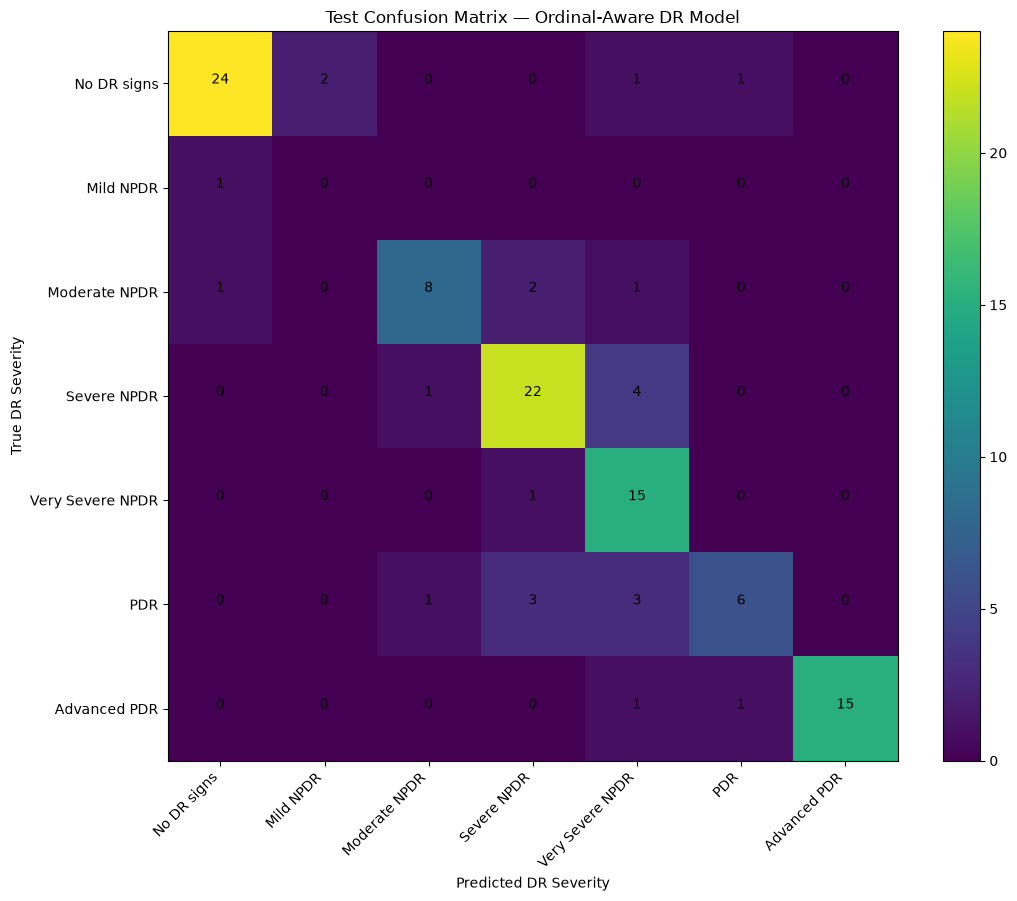


TEST CLASS DISTRIBUTION
           Class  True_Count  Predicted_Count
     No DR signs          28               26
       Mild NPDR           1                2
   Moderate NPDR          12               10
     Severe NPDR          27               28
Very Severe NPDR          16               25
             PDR          13                8
    Advanced PDR          17               15

CELL 5 COMPLETED SUCCESSFULLY


In [13]:
# ============================================================
# CELL 5 — FINAL UNTOUCHED TEST EVALUATION
# ============================================================

import os
import json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    cohen_kappa_score,
    mean_absolute_error,
    classification_report
)

# ============================================================
# LOAD BEST CHECKPOINT
# ============================================================

print("=" * 90)
print("LOADING BEST ORDINAL-AWARE MODEL")
print("=" * 90)

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.to(DEVICE)

model.eval()

print(
    f"Checkpoint epoch : "
    f"{checkpoint.get('epoch', 'N/A')}"
)

print(
    f"Validation QWK   : "
    f"{checkpoint.get('best_qwk', 'N/A'):.4f}"
)

print(
    f"Model loaded from : "
    f"{BEST_MODEL_PATH}"
)

# ============================================================
# TEST INFERENCE
# ============================================================

all_labels = []
all_predictions = []

all_class_probabilities = []
all_ordinal_probabilities = []

test_losses = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        if torch.cuda.is_available():

            images = images.contiguous(
                memory_format=torch.channels_last
            )

        # ----------------------------------------------------
        # FORWARD
        # ----------------------------------------------------

        if USE_AMP:

            with torch.autocast(
                device_type="cuda",
                dtype=torch.float16
            ):

                outputs = model(
                    images
                )

                losses = criterion(
                    outputs,
                    labels
                )

        else:

            outputs = model(
                images
            )

            losses = criterion(
                outputs,
                labels
            )

        test_losses.append(
            losses["total"].item()
        )

        # ----------------------------------------------------
        # CLASSIFICATION PROBABILITIES
        # ----------------------------------------------------

        class_probabilities = torch.softmax(
            outputs["classification_logits"],
            dim=1
        )

        # ----------------------------------------------------
        # ORDINAL PREDICTIONS
        # ----------------------------------------------------

        ordinal_predictions = ordinal_prediction(
            outputs["ordinal_logits"]
        )

        ordinal_probabilities = torch.sigmoid(
            outputs["ordinal_logits"]
        )

        # ----------------------------------------------------
        # STORE
        # ----------------------------------------------------

        all_labels.extend(
            labels.cpu().numpy()
        )

        all_predictions.extend(
            ordinal_predictions.cpu().numpy()
        )

        all_class_probabilities.append(
            class_probabilities.cpu().numpy()
        )

        all_ordinal_probabilities.append(
            ordinal_probabilities.cpu().numpy()
        )


# ============================================================
# CONVERT TO NUMPY
# ============================================================

y_true = np.asarray(
    all_labels,
    dtype=np.int64
)

y_pred = np.asarray(
    all_predictions,
    dtype=np.int64
)

class_probabilities = np.concatenate(
    all_class_probabilities,
    axis=0
)

ordinal_probabilities = np.concatenate(
    all_ordinal_probabilities,
    axis=0
)

# ============================================================
# TEST METRICS
# ============================================================

accuracy = accuracy_score(
    y_true,
    y_pred
)

balanced_accuracy = balanced_accuracy_score(
    y_true,
    y_pred
)

macro_precision = precision_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

weighted_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

cohen_kappa = cohen_kappa_score(
    y_true,
    y_pred
)

qwk = cohen_kappa_score(
    y_true,
    y_pred,
    weights="quadratic"
)

ordinal_mae = mean_absolute_error(
    y_true,
    y_pred
)

test_loss = np.mean(
    test_losses
)

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=np.arange(NUM_CLASSES)
)

# ============================================================
# SPECIFICITY
# ============================================================

specificities = []

for i in range(NUM_CLASSES):

    true_positive = cm[i, i]

    false_positive = (
        cm[:, i].sum()
        -
        true_positive
    )

    false_negative = (
        cm[i, :].sum()
        -
        true_positive
    )

    true_negative = (
        cm.sum()
        -
        true_positive
        -
        false_positive
        -
        false_negative
    )

    if (
        true_negative
        +
        false_positive
    ) > 0:

        specificity = (
            true_negative
            /
            (
                true_negative
                +
                false_positive
            )
        )

    else:

        specificity = np.nan

    specificities.append(
        specificity
    )

macro_specificity = np.nanmean(
    specificities
)

# ============================================================
# PER-CLASS REPORT
# ============================================================

report = classification_report(
    y_true,
    y_pred,
    labels=np.arange(NUM_CLASSES),
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

per_class_rows = []

for i, class_name in enumerate(
    CLASS_NAMES
):

    per_class_rows.append({

        "Class":
            class_name,

        "Label":
            i,

        "Support":
            int(
                np.sum(
                    y_true == i
                )
            ),

        "Precision":
            report[
                class_name
            ][
                "precision"
            ],

        "Recall":
            report[
                class_name
            ][
                "recall"
            ],

        "F1":
            report[
                class_name
            ][
                "f1-score"
            ],

        "Specificity":
            specificities[i]
    })

per_class_df = pd.DataFrame(
    per_class_rows
)

# ============================================================
# PRINT FINAL RESULTS
# ============================================================

print()
print("=" * 90)
print("FINAL TEST RESULTS")
print("=" * 90)

print(
    f"Test samples          : {len(y_true)}"
)

print(
    f"Test loss             : {test_loss:.4f}"
)

print(
    f"Accuracy              : {accuracy:.4f}"
)

print(
    f"Balanced Accuracy     : {balanced_accuracy:.4f}"
)

print(
    f"Macro Precision       : {macro_precision:.4f}"
)

print(
    f"Macro Recall          : {macro_recall:.4f}"
)

print(
    f"Macro Specificity     : {macro_specificity:.4f}"
)

print(
    f"Macro F1              : {macro_f1:.4f}"
)

print(
    f"Weighted F1           : {weighted_f1:.4f}"
)

print(
    f"Cohen's Kappa         : {cohen_kappa:.4f}"
)

print(
    f"Quadratic Weighted Kappa : {qwk:.4f}"
)

print(
    f"Ordinal MAE           : {ordinal_mae:.4f}"
)

print("=" * 90)

# ============================================================
# PER-CLASS RESULTS
# ============================================================

print()
print("=" * 90)
print("PER-CLASS PERFORMANCE")
print("=" * 90)

print(
    per_class_df.to_string(
        index=False
    )
)

# ============================================================
# CONFUSION MATRIX
# ============================================================

print()
print("=" * 90)
print("CONFUSION MATRIX")
print("=" * 90)

print(
    pd.DataFrame(
        cm,
        index=CLASS_NAMES,
        columns=CLASS_NAMES
    )
)

# ============================================================
# SAVE RESULTS
# ============================================================

test_results = {

    "test_samples":
        len(y_true),

    "test_loss":
        float(test_loss),

    "accuracy":
        float(accuracy),

    "balanced_accuracy":
        float(balanced_accuracy),

    "macro_precision":
        float(macro_precision),

    "macro_recall":
        float(macro_recall),

    "macro_specificity":
        float(macro_specificity),

    "macro_f1":
        float(macro_f1),

    "weighted_f1":
        float(weighted_f1),

    "cohen_kappa":
        float(cohen_kappa),

    "quadratic_weighted_kappa":
        float(qwk),

    "ordinal_mae":
        float(ordinal_mae),

    "best_validation_qwk":
        float(
            checkpoint["best_qwk"]
        ),

    "best_epoch":
        int(
            checkpoint["epoch"]
        )
}

with open(
    RESULTS_DIR /
    "final_test_results.json",
    "w"
) as f:

    json.dump(
        test_results,
        f,
        indent=4
    )

per_class_df.to_csv(
    RESULTS_DIR /
    "per_class_test_metrics.csv",
    index=False
)

pd.DataFrame(
    cm,
    index=CLASS_NAMES,
    columns=CLASS_NAMES
).to_csv(
    RESULTS_DIR /
    "test_confusion_matrix.csv"
)

# ============================================================
# CONFUSION MATRIX FIGURE
# ============================================================

plt.figure(
    figsize=(11, 9)
)

plt.imshow(
    cm,
    interpolation="nearest"
)

plt.title(
    "Test Confusion Matrix — Ordinal-Aware DR Model"
)

plt.colorbar()

tick_marks = np.arange(
    NUM_CLASSES
)

plt.xticks(
    tick_marks,
    CLASS_NAMES,
    rotation=45,
    ha="right"
)

plt.yticks(
    tick_marks,
    CLASS_NAMES
)

threshold = (
    cm.max() / 2.0
)

for i in range(
    NUM_CLASSES
):

    for j in range(
        NUM_CLASSES
    ):

        plt.text(
            j,
            i,
            str(cm[i, j]),
            horizontalalignment="center"
        )

plt.ylabel(
    "True DR Severity"
)

plt.xlabel(
    "Predicted DR Severity"
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR /
    "test_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# PREDICTION DISTRIBUTION
# ============================================================

true_counts = np.bincount(
    y_true,
    minlength=NUM_CLASSES
)

pred_counts = np.bincount(
    y_pred,
    minlength=NUM_CLASSES
)

distribution_df = pd.DataFrame({

    "Class":
        CLASS_NAMES,

    "True_Count":
        true_counts,

    "Predicted_Count":
        pred_counts
})

print()
print("=" * 90)
print("TEST CLASS DISTRIBUTION")
print("=" * 90)

print(
    distribution_df.to_string(
        index=False
    )
)

distribution_df.to_csv(
    RESULTS_DIR /
    "test_prediction_distribution.csv",
    index=False
)

print()
print("=" * 90)
print("CELL 5 COMPLETED SUCCESSFULLY")
print("=" * 90)